# E04 -- EXPERIMENT SPECIFICATION / CONTRACT (enhancement cell 1)

> This first cell is the machine-readable **experiment contract** added by the
> research-grade enhancement protocol (`prompt_1`). It describes the experiment
> so that another researcher or AI agent can understand it without reverse-
> engineering the notebook. All numbers quoted in *"Recorded-run evidence"*
> notes come from the execution recorded in this notebook's saved outputs
> (run `F_SIBS_r_2026-09-21_1`, dated 2026-09-21); they are not re-typed
> estimates. Original algorithm code below is preserved **unchanged**.

## 7.1 Experiment identity

```text
Experiment ID:   E04
Experiment title: Practical compressor vs. JPEG / JPEG2000 (dynamic-SSIM stopping, entropy-coded BPP)
Research context: F-SIBS -- federated sparse image basis sharing; the compression-efficiency
                  experiment of the modular F-SIBS evaluation suite (E00-E10).
Paper section:    [REQUIRES CONFIRMATION] (paper section mapping is not stated in the notebook)
Purpose:          Quantify how competitive the sparse-basis image compressors (OMP, SIBS1-4,
                  and federated F-SIBS_1-4 re-encoding over the augmented dictionary) are
                  against JPEG / JPEG2000 at equal SSIM, with a practical entropy-coded
                  bit model, and decompose the total bit budget into coefficient vs.
                  federated-uplink cost.
```

## 7.2 Scientific objective

Establish whether F-SIBS-class distributed sparse coding delivers real (delivered-file)
bitrate savings relative to established image codecs, and what the federation itself costs
in bits. The experiment is necessary because the raw `bpp_sparse` cost model used elsewhere
in the suite overstates the delivered bitrate; a practical rate measurement (fixed-point
coefficient quantisation + entropy coding of the actually transmitted symbols) is required
before any rate-distortion claim is scientifically defensible.

## 7.3 Research questions

```text
RQ1: At matched SSIM, do the entropy-coded sparse compressors (OMP / SIBS1-4, local
     dictionaries) need less rate than JPEG / JPEG2000 (Bjontegaard BD-rate)?
RQ2: Does dynamic-SSIM stopping deliver a better rate than fixed-k stopping at equal quality?
RQ3: What does re-encoding over the FEDERATED dictionary [Phi, global_dict] add in quality,
     and what does the federated uplink add in bits (bit-budget decomposition)?
RQ4: How do dataset, node count N, novelty threshold tau and run-to-run variability affect
     the federated rate-distortion trade-off (extension sweep)?
```

## 7.4 Hypotheses

```text
H1: [REQUIRES CONFIRMATION] -- no formal hypothesis is stated in the notebook.
    (The experiment is framed as measurement/comparison, not hypothesis testing.)
```

## 8 Datasets / data sources

Recorded node catalogue (printed by `build_data_bundle` at setup):

| Dataset | Source | Nodes used | Subjects | Image shape | Federated groups |
|---|---|---|---|---|---|
| coil20 | COIL-20 (1440 files, 20 objects), cached under `fsibs_data/` | 80 nodes (one view of one object per node) | 20 | 128x128 | `coil20_same_object` 20 groups x 4 members; `coil20_cross_object` 5 groups x 4 members |
| dino | Middlebury `dinoSparseRing` (16 PNGs) | 16 nodes | 1 scene | 96x128 | `dino_ring` 1 group x 16 members |
| temple | Middlebury `templeSparseRing` (16 PNGs) | 16 nodes | 1 scene | 96x128 | `temple_ring` 1 group x 16 members |

* Dataset properties vs. experiment subset: COIL-20 contains 1440 images; the node pool
  keeps 80 (one view per object). The full dino/temple rings (16 views each) are used.
* Preprocessing: grayscale conversion and per-dataset geometry enforced by `fsibs.datasets`
  (details of resizing are inside the package: [REQUIRES CONFIRMATION] for exact params).
* Random selection: node groups are deterministic given the seed protocol; no augmented
  splits are created here.

## 9 Methods and algorithms

| Method | Role | Implementation source | Notes |
|---|---|---|---|
| OMP | baseline sparse coder | `fsibs.entropy_coding._run_algorithm_generic` | k-sparse OMP on local dict Phi |
| SIBS1..SIBS4 | local sparse-in-basis encoders (proposed family, local) | same dispatch | fixed behaviour, untouched |
| F-SIBS_1..F-SIBS_4 | federated variants, paired 1:1 with SIBSk | `fsibs.federated.f_sibs_simulate` (via `ACTIVE_F_SIBS_VARIANTS`) | tau=0.95 federation for the completion cell; `return_transmitted_vectors=True` for uplink metering |
| JPEG | codec anchor | `fsibs.codecs.jpeg_encode_decode` | quality sweep `JPEG_QUALITIES` (values live in `fsibs.protocol`: [REQUIRES CONFIRMATION]) |
| JPEG2000 | codec anchor | `fsibs.codecs.jpeg2000_encode_decode` | rate sweep `J2K_RATES` ([REQUIRES CONFIRMATION]) |
| Bjontegaard BD-rate / BD-PSNR | R-D comparison metric | local helpers `bd_rate` / `bd_psnr` (this notebook, unchanged) | VCEG-M33 cubic fit over common quality interval; SSIM used as the quality axis |

All algorithm implementations are treated as **black-box scientific components**: this
enhancement preserves their code byte-for-byte.

## 10 Experimental design

* **Independent variables**: algorithm (`OMP, SIBS1..4, F-SIBS_1..4`), stopping criterion
  (`fixed_k` in {2,4,8,16,24} vs `ssim` targets {0.50..0.95 step 0.05}), coding
  (`raw` vs `entropy`), dataset (`coil20, dino, temple`), extension: N (2/4 for coil20,
  8/16 for dino, temple), tau ({0.3, 0.6, 0.9, 0.95, 0.99}), run index (3 runs).
* **Dependent variables**: SSIM, PSNR, NMSE, BPP (raw and entropy-coded), avg_k,
  encode_time_s, compression_ratio, BD-rate %, BD-PSNR, coefficient vs federated-uplink
  BPP split.
* **Controlled variables**: DELTA (column stride, value in `fsibs.protocol`:
  [REQUIRES CONFIRMATION]), coefficient quantisation `DYNAMIC_SSIM_BITS_COEFF=16` bits,
  sparsity ceiling `DYNAMIC_SSIM_K_MAX=24`, K_SUMMARY=8, K_GLOBAL=16, N_ROUNDS_FULL,
  EPS_CONV (values in `fsibs.protocol`: [REQUIRES CONFIRMATION]), 8-bit grayscale
  reference (`RAW_BITS_PER_PIXEL=8.0`).
* **Trials**: comparison suite 112 nodes x 5 local algorithms x (5 fixed-k + 10
  dynamic-SSIM) conditions x 2 codings = 16,800 rows (recorded). Extension: 90
  (dataset, N, tau, run) configs x 10 targets = 900 rows (recorded), 3 runs each.

## 11 Parameters (inventory, from Cell 3 configuration)

| Parameter | Value/Range | Type | Fixed/Variable | Purpose |
|---|---|---|---|---|
| SELECTED_DATASETS | coil20, dino, temple | config | fixed | datasets in run |
| SELECTED_ALGORITHMS | OMP + 4x(SIBSk, F-SIBS_k) | config | fixed | pairing rule respected |
| DYNAMIC_SSIM_TARGETS | 0.50..0.95 step 0.05 | sweep | variable | SSIM stopping targets |
| COMPARISON_K_VALUES | 2,4,8,16,24 (=K_SWEEP) | sweep | variable | fixed-k grid |
| DYNAMIC_SSIM_K_MAX | 24 | derived | fixed | stopping ceiling |
| DYNAMIC_SSIM_BITS_COEFF | 16 bits | fixed | fixed | coefficient quantiser |
| EXP4_EXT_N_RUNS | 3 (seeds 42..44) | fixed | fixed | extension repetitions |
| EXP4_EXT_N_FRACTIONS | 0.5, 1.0 | sweep | variable | node-count grid |
| EXP4_EXT_TAU_SWEEP | 0.3,0.6,0.9,0.95,0.99 | sweep | variable | novelty threshold |
| RAW_BITS_PER_PIXEL | 8.0 | fixed | fixed | compression-ratio reference |
| JPEG_QUALITIES / J2K_RATES | from fsibs.protocol | fixed | fixed | codec anchors |
| RNG_SEED | fsibs.protocol | fixed | fixed | global seed |

## 12 Replication and randomness

Comparison suite and BD-rate sections are single-pass deterministic (fixed per-node
computation; no stochastic training). The extension repeats every (dataset, N, tau)
configuration `EXP4_EXT_N_RUNS=3` times with seeds 42+run. Federation runs use seed=42.
No cross-validation is used. Reported dispersion for the extension is mean +/- std over
the 3 runs.

## 13 Evaluation metrics

| Metric | Direction | Definition / notes | Aggregation |
|---|---|---|---|
| SSIM | higher better | mean structural similarity, skimage (MS-SSIM unavailable -> SSIM fallback) | per-node mean; dataset/node means |
| PSNR (dB) | higher better | peak SNR on 8-bit images | per-node mean |
| NMSE | lower better | normalised squared error | per-node mean |
| BPP | lower better | bits/pixel; raw cost model vs entropy-coded delivered bits | per-node mean |
| avg_k | descriptive | mean number of selected bases | per-node mean |
| BD-rate % | lower (negative) better | Bjontegaard integral, SSIM quality axis, entropy-coded curves | per method/anchor |
| compression ratio | higher better | 8 bpp / total entropy-coded BPP | mean over sweep |
| encode_time_s | descriptive | wall-clock per encode | recorded per row |

## Outputs produced by this notebook (recorded run)

Tables: `dynamic_ssim_comparison_suite_results.csv`, `fsibs_variant_comparison_results.csv`,
`exp4_federated_rd_table.csv`, `exp4_jpeg_baseline_rd.csv`, `exp4_jpeg2000_baseline_rd.csv`,
`exp4_avg_compression_ratio.csv`, `exp4_bd_rate_vs_jpeg_jpeg2000.csv`,
`exp4_ext_multi_dataset_N_tau_rd_table.csv`, `exp4_ext_multi_dataset_N_tau_raw_runs.csv`,
`exp4_ext_jpeg_jpeg2000_baselines_per_dataset.csv`, `exp4_ext_summary_by_dataset_N_tau.csv`.
Figures: `comparison_suite_rd_curves.png`, `fsibs_variant_k_ssim_comparison.png`,
`exp4_bd_rate_bars.png`, `exp4_federated_rd_curve.png`, `exp4_bit_budget_stacked.png`,
`exp4_ext_rd_curves_by_dataset_N_tau.png`, `exp4_ext_compression_ratio_vs_N_tau.png`.
Manifest: `results/manifests/E04.json` (registered at the end of the notebook).

## Known recorded anomalies (preserved, flagged -- not silently fixed)

1. **F-SIBS_1..4 BD-rate rows are NaN** in the recorded output. The BD integrator returns
   NaN when the two R-D curves' common quality interval is empty or degenerate; the
   federated F-SIBS entropy-coded curves (re-encoded over the augmented dictionary on the
   16-node dino ring) appear to have a degenerate overlap with the JPEG/JPEG2000 anchors.
   Status: [REQUIRES CONFIRMATION] -- needs author decision before paper use. NOT fixed here.
2. **Federated uplink dominates the bit budget** at tau=0.95 on dino_ring (4.7496 bpp/node
   amortised), so total BPP ~ 4.88 and compression ratio ~ 1.6:1 -- unfavourable vs. JPEG's
   9.9:1 average on the same group. Preserved as a genuine (negative) result; see E06 for
   the tau-dependent remedy.
3. Environment notes recorded at import: this scikit-image has **no MS-SSIM -> falls back
   to SSIM**; `imagecodecs` is **not installed, so JPEG-LS runs in MOCKED mode** (raw 8bpp
   passthrough). No E04 section uses JPEG-LS, but any cross-experiment JPEG-LS number would
   be affected: [REQUIRES CONFIRMATION] if JPEG-LS results exist elsewhere in the suite.


# E04 -- Practical compressor vs. JPEG / JPEG2000 (dynamic-SSIM, entropy-coded BPP)

Dynamic-SSIM stopping and entropy-coded BPP for OMP / SIBS1-4 (comparison suite), the federated completion over the augmented dictionary, the multi-dataset / multi-N / multi-tau / multi-run extension, the Bjontegaard BD-rate table vs. JPEG and JPEG2000 and the bit-budget decomposition.

* **Independent:** run this notebook top-to-bottom in a fresh kernel; it needs no other notebook's in-memory state.
* **Needs:** datasets; OMP / SIBS1-4 must be among the selected algorithms for the comparison suite.
* **Writes:** `results/experiment_4/` + FIG_DIR tables and figures.
* **Shared code:** imported from the `fsibs` package (see `README.md`); everything experiment-specific is in this notebook.

In [1]:
# ============================================================
# F-SIBS MODULAR - PROJECT LOCATION + IMPORTS
# ============================================================

import sys,time, os
from pathlib import Path

# ------------------------------------------------------------
# Project location
# ------------------------------------------------------------

PROJECT_ROOT = Path("/home/ahmed_omara/F_SIBS_Modular").resolve()
PACKAGE_ROOT = PROJECT_ROOT / "fsibs"

# Validate project root
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"\nF-SIBS project directory was not found:\n"
        f"  {PROJECT_ROOT}"
    )

# Validate fsibs package
if not PACKAGE_ROOT.exists():
    raise FileNotFoundError(
        f"\nF-SIBS package directory was not found:\n"
        f"  {PACKAGE_ROOT}\n\n"
        f"Project contents:\n"
        + "\n".join(f"  {p.name}" for p in PROJECT_ROOT.iterdir())
    )

if not (PACKAGE_ROOT / "__init__.py").exists():
    raise FileNotFoundError(
        f"\nF-SIBS package exists, but __init__.py was not found:\n"
        f"  {PACKAGE_ROOT / '__init__.py'}"
    )

# Add project root to Python import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Use F-SIBS project as working directory
import os
os.chdir(PROJECT_ROOT)

# ------------------------------------------------------------
# Standard imports
# ------------------------------------------------------------

import functools
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fsibs.codecs import jpeg2000_encode_decode, jpeg_encode_decode
from fsibs.datasets import build_data_bundle
from fsibs.entropy_coding import _encode_column_dynamic_ssim, _encode_column_fixed, _entropy_bits_per_symbol, _run_algorithm_generic, entropy_code_sparse_representation, quantize_coeffs
from fsibs.env import setup_environment
from fsibs.federated import F_SIBS_VARIANT_TO_SIBS
from fsibs.io_utils import save_figure, save_table
from fsibs.metrics import nmse, psnr, ssim
from fsibs.parallel import PBAR_FORMAT, describe, run_part
from fsibs.runtime import init_run, new_manifest, save_manifest
from fsibs.selection import prompt_numbers, prompt_selection, resolve_selection

NOTE: this scikit-image has no MS-SSIM -> falls back to SSIM
NOTE: `imagecodecs` is not installed -- JPEG-LS will run in MOCKED mode (raw 8bpp passthrough). Install with `pip install imagecodecs` for the genuine CharLS-backed codec.


## Configuration
All settings of this experiment.

In [2]:
# ------------------------------------------------------------------------------------
# EXPERIMENT CONFIGURATION -- everything that can differ between experiments lives HERE,
# in this notebook.  Edit freely; no other notebook or module is affected.
# ------------------------------------------------------------------------------------
RUN_DIR_POLICY = "latest"      # "latest": re-use the newest F_SIBS_r_<date>_<n> folder (shared with the other
                               #   notebooks) | "new": start a fresh run folder | or an explicit folder path
INTERACTIVE_SELECTION = False  # True: ask for datasets / algorithms with the original input() menus

# Datasets: any of "coil20", "coil100", "eth80", "epfl", "dino", "temple"
SELECTED_DATASETS = ["coil20", "dino", "temple"]
# Algorithms: SIBSk and F-SIBS_k must be selected together (pairing rule); all other baselines are free
SELECTED_ALGORITHMS = [
    "OMP",
    "SIBS1",
    "F-SIBS_1",
    "SIBS2",
    "F-SIBS_2",
    "SIBS3",
    "F-SIBS_3",
    "SIBS4",
    "F-SIBS_4",
]

# ---- shared evaluation-protocol values (defaults from fsibs.protocol; override here for THIS experiment only) ----
from fsibs import protocol as P
RNG_SEED = P.RNG_SEED
COIL_VIEWS = P.COIL_VIEWS
COIL100_VIEWS = P.COIL100_VIEWS
ETH80_VIEWS = P.ETH80_VIEWS
COIL100_MAX_OBJECTS = P.COIL100_MAX_OBJECTS
ETH80_MAX_OBJECTS_PER_CAT = P.ETH80_MAX_OBJECTS_PER_CAT
EPFL_MAX_FRAMES = P.EPFL_MAX_FRAMES
EPFL_TARGET_HW = P.EPFL_TARGET_HW
COIL_N_CROSS_GROUPS = P.COIL_N_CROSS_GROUPS
K_SWEEP = P.K_SWEEP
TAU_SWEEP = P.TAU_SWEEP
GEOMETRY = P.GEOMETRY
DELTA = P.DELTA
K_SUMMARY = P.K_SUMMARY
K_GLOBAL = P.K_GLOBAL
N_ROUNDS_FULL = P.N_ROUNDS_FULL
EPS_CONV = P.EPS_CONV
JPEG_QUALITIES = P.JPEG_QUALITIES
J2K_RATES = P.J2K_RATES

# ---- settings specific to this experiment ----
USE_PARALLEL_SWEEP = True                            # E1: flip to False to force serial fallback
DYNAMIC_SSIM_TARGETS = [round(0.50 + 0.05 * i, 2) for i in range(10)]  # 0.50..0.95
# ---- comparison suite scope: local, single-node sparse algorithms only --
_COMPARISON_ALGORITHMS_AVAILABLE = ["OMP", "SIBS1", "SIBS2", "SIBS3", "SIBS4"]
COMPARISON_K_VALUES = list(K_SWEEP)          # reuse the existing k grid
COMPARISON_SSIM_TARGETS = DYNAMIC_SSIM_TARGETS
COMPARISON_MAX_NODES_PER_DATASET = None      # None = every node (slower,
                                              # matches every other dataset's
                                              # full-run default); set an
                                              # int to subsample for speed
# ---- knobs (safe to tune for a quicker/slower run; everything else is
#      reused unchanged from the base Experiment 4 cell above) ----------
EXP4_EXT_N_RUNS = 3                      # independent runs per (dataset, N, tau)
EXP4_EXT_N_FRACTIONS = [0.5, 1.0]        # node-count grid, as a fraction of each
                                          # dataset's representative group size
                                          # (rounded, floored at 2 nodes)
EXP4_EXT_TAU_SWEEP = sorted(set(
    list(globals().get("TAU_SWEEP", [0.3, 0.6, 0.9, 0.99])) + [0.95]))
EXP4_EXT_DYNAMIC_SSIM_TARGETS = DYNAMIC_SSIM_TARGETS     # unchanged: full grid
EXP4_EXT_RAW_BITS_PER_PIXEL = 8.0        # same convention as the base cell
DYNAMIC_SSIM_K_MAX = max(K_SWEEP)     # hard ceiling per column so a target that is never reached still
                                       # terminates; reuses the same max sparsity already swept above
DYNAMIC_SSIM_BITS_COEFF = 16          # same fixed-point coefficient-resolution assumption as bpp_sparse's
                                       # bits_coeff, reused as the quantization grid the entropy coder is applied to

## Setup
Run folder, selection and (when needed) datasets.

In [3]:
setup_environment(RNG_SEED)                       # warnings, global seed, Matplotlib defaults
describe()                                       # CPU / platform banner
run = init_run(RUN_DIR_POLICY)                    # resolves F_SIBS_r_<date>_<n> and creates its folders
RUN_DIR, FIG_DIR, RESULTS_DIR, DATA_DIR = run.RUN_DIR, run.FIG_DIR, run.RESULTS_DIR, run.DATA_DIR
EXPERIMENT_MANIFEST = new_manifest()              # files this notebook registers as outputs
print("RUN_DIR     :", RUN_DIR)
print("DATA_DIR    :", DATA_DIR)

# ---- algorithm / dataset selection (enforces the SIBSk <-> F-SIBS_k pairing rule) ----
if INTERACTIVE_SELECTION:
    SELECTED_DATASETS, SELECTED_ALGORITHMS = prompt_selection()
    _k_ceiling = prompt_numbers("Choose the K-ceiling for the SSIM-based stopping criterion", K_SWEEP)
    if len(_k_ceiling) != 1:
        raise ValueError("Please select exactly ONE K-ceiling.")
    DYNAMIC_SSIM_K_MAX = _k_ceiling[0]
    _bits_coeff_sel = prompt_numbers("Choose the coefficient quantization resolution", [8, 10, 12, 14, 16])
    if len(_bits_coeff_sel) != 1:
        raise ValueError("Please select exactly ONE coefficient quantization resolution.")
    DYNAMIC_SSIM_BITS_COEFF = _bits_coeff_sel[0]
sel = resolve_selection(SELECTED_DATASETS, SELECTED_ALGORITHMS)
SELECTED_DATASETS, SELECTED_ALGORITHMS = sel.SELECTED_DATASETS, sel.SELECTED_ALGORITHMS
SELECTED_METHODS = sel.SELECTED_METHODS
SELECTED_METHODS_SET = sel.SELECTED_METHODS_SET
ACTIVE_F_SIBS_VARIANTS = sel.ACTIVE_F_SIBS_VARIANTS

# ---- datasets: acquisition (cached in DATA_DIR), node pools, federated groups ----
data = build_data_bundle(
    SELECTED_DATASETS, DATA_DIR,
    coil_views=COIL_VIEWS, coil100_views=COIL100_VIEWS, eth80_views=ETH80_VIEWS,
    coil100_max_objects=COIL100_MAX_OBJECTS, eth80_max_objects_per_cat=ETH80_MAX_OBJECTS_PER_CAT,
    epfl_max_frames=EPFL_MAX_FRAMES, epfl_target_hw=EPFL_TARGET_HW,
    coil_n_cross_groups=COIL_N_CROSS_GROUPS)
POOLS, PHI, GROUPS, CONV_SPECS = data.POOLS, data.PHI, data.GROUPS, data.CONV_SPECS
_ds6, _cfg6, _gi6, _g6, _imgs6, _Phi6 = data.rep   # representative federated group (Cell-3 names)
_pick_group = data.pick_group

# ---- settings derived from the selection above ----
COMPARISON_ALGORITHMS = [a for a in _COMPARISON_ALGORITHMS_AVAILABLE
                         if a in SELECTED_METHODS_SET]

# E4-extension dispatch uses the shared process-pool helper with this notebook's own parallel flag
_run_part = functools.partial(run_part, use_parallel=USE_PARALLEL_SWEEP)

effective_cpu_count() = 96 | platform = Linux | MULTIPROCESSING_AVAILABLE = True
RUN_DIR     : /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1
DATA_DIR    : /home/ahmed_omara/F_SIBS_Modular/fsibs_data
EXPERIMENT CONFIGURATION

Selected datasets:
    COIL-20
    Middlebury Dino
    Middlebury Temple

Selected SIBS <-> F-SIBS pairs:
    SIBS1  + F-SIBS_1 
    SIBS2  + F-SIBS_2 
    SIBS3  + F-SIBS_3 
    SIBS4  + F-SIBS_4 

Selected other baselines:
    OMP

Final algorithms (SELECTED_METHODS):
    OMP
    SIBS1
    F-SIBS_1
    SIBS2
    F-SIBS_2
    SIBS3
    F-SIBS_3
    SIBS4
    F-SIBS_4
Configuration valid -- proceeding with the experiment campaign.
Active local SIBS methods (from SELECTED_BASELINES / SELECTED_SIBS_VARIANTS): ['SIBS1', 'SIBS2', 'SIBS3', 'SIBS4']
Active F-SIBS variants (from the user's paired SIBSk<->F-SIBS_k selection): ['F-SIBS_1', 'F-SIBS_2', 'F-SIBS_3', 'F-SIBS_4']


Middlebury datasets: 100% complete |██████████| 2/2 [00:00<00:00]


COIL-20 images: 1440 files in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/Image_Classfiation_Coil20-master/dataset
dino    images: 16 PNGs in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/dinoSparseRing
temple  images: 16 PNGs in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/templeSparseRing
COIL-100: not selected -> acquisition skipped
ETH-80: not selected -> acquisition skipped
EPFL: not selected -> acquisition skipped


COIL-20 objects: 100% complete |██████████| 20/20 [00:00<00:00]
dino frames: 100% complete |██████████| 16/16 [00:00<00:00]
temple frames: 100% complete |██████████| 16/16 [00:00<00:00]


Node catalogue (one view of one object per node):
dataset  nodes  subjects  img_shape
 coil20     80        20 (128, 128)
   dino     16         1  (96, 128)
 temple     16         1  (96, 128)

federated node groups:
  coil20_same_object      20 groups | 4 members each
  coil20_cross_object      5 groups | 4 members each
  dino_ring                1 groups | 16 members each
  temple_ring              1 groups | 16 members each

NODE_CATALOG built: 112 rows across 3 datasets


## Experiment-specific helpers
Defined here (not in `fsibs`) because no other experiment uses them.

In [4]:
def bd_rate(R1, PSNR1, R2, PSNR2):
    """Bjontegaard delta-rate (%) between two R-D curves (VCEG-M33 / JVET
    convention): a cubic polynomial log-rate = f(quality) is fitted per
    curve and integrated over the COMMON quality interval; BD-rate is
    100 * (exp(avg_logR2 - avg_logR1) - 1).
    R1, PSNR1 : anchor curve rates (any positive unit) and qualities
    R2, PSNR2 : test curve
    Returns dR in % : NEGATIVE = test needs LESS rate for the same quality.
    At least 3 points per curve are required for the cubic fit (2nd-order
    fallback when only 3 points are available is NOT used - the convention
    requires 4+ points for cubic; we degrade to quadratic below 4 with a
    documented note since R-D sweeps here produce >= 5 points).
    """
    R1 = np.asarray(R1, float); PSNR1 = np.asarray(PSNR1, float)
    R2 = np.asarray(R2, float); PSNR2 = np.asarray(PSNR2, float)
    if min(len(R1), len(R2)) < 3:
        return float("nan")
    o1 = np.argsort(PSNR1); o2 = np.argsort(PSNR2)   # sort by quality
    P1, lR1 = PSNR1[o1], np.log(R1[o1])
    P2, lR2 = PSNR2[o2], np.log(R2[o2])
    Pmin = max(P1[0], P2[0]); Pmax = min(P1[-1], P2[-1])
    if Pmax <= Pmin:
        return float("nan")
    deg = 3 if min(len(P1), len(P2)) >= 4 else 2
    p1 = np.polyfit(P1, lR1, deg)
    p2 = np.polyfit(P2, lR2, deg)
    Pi = np.linspace(Pmin, Pmax, 100)
    avg_lR1 = float(np.mean(np.polyval(p1, Pi)))
    avg_lR2 = float(np.mean(np.polyval(p2, Pi)))
    return float(100.0 * (np.exp(avg_lR2 - avg_lR1) - 1.0))

def bd_psnr(R1, PSNR1, R2, PSNR2):
    """Bjontegaard delta-PSNR (dB): cubic quality = f(log-rate) fitted per
    curve and integrated over the COMMON log-rate interval. Positive =
    test delivers HIGHER quality at equal rate."""
    R1 = np.asarray(R1, float); PSNR1 = np.asarray(PSNR1, float)
    R2 = np.asarray(R2, float); PSNR2 = np.asarray(PSNR2, float)
    if min(len(R1), len(R2)) < 3:
        return float("nan")
    o1 = np.argsort(R1); o2 = np.argsort(R2)
    lR1, P1 = np.log(R1[o1]), PSNR1[o1]
    lR2, P2 = np.log(R2[o2]), PSNR2[o2]
    lRmin = max(lR1[0], lR2[0]); lRmax = min(lR1[-1], lR2[-1])
    if lRmax <= lRmin:
        return float("nan")
    deg = 3 if min(len(P1), len(P2)) >= 4 else 2
    p1 = np.polyfit(lR1, P1, deg)
    p2 = np.polyfit(lR2, P2, deg)
    lRi = np.linspace(lRmin, lRmax, 100)
    return float(np.mean(np.polyval(p2, lRi) - np.polyval(p1, lRi)))

## Experiment

In [5]:
# ============================================================
# EXPERIMENT 4 - Practical compressor vs. JPEG / JPEG2000 (original
# Cells 39-42, 52, 52b). Dynamic-SSIM stopping + entropy-coded BPP for
# OMP/SIBS1-4 (comparison suite), then the federated completion (R-D
# curve over the AUGMENTED dictionary [Phi, global_dict]) and the
# multi-dataset / multi-N / multi-tau / multi-run extension. NEW
# (V3.2): Bjontegaard BD-rate table vs. JPEG & JPEG2000 and the stacked
# bit-budget decomposition figure. COMPARISON_DATASETS is derived here
# (it depends on POOLS); every other knob lives in Cell 1.
# ============================================================

COMPARISON_DATASETS = list(POOLS.keys())     # every pool built in this run (Cell 3)


print("Dynamic-SSIM / comparison-suite configuration:")
print("  SSIM target sweep   =", DYNAMIC_SSIM_TARGETS)
print("  k ceiling            =", DYNAMIC_SSIM_K_MAX)
print("  fixed-k grid         =", COMPARISON_K_VALUES)
print("  algorithms compared  =", COMPARISON_ALGORITHMS,
      "(from SELECTED_METHODS; %s not selected -> excluded)"
      % [a for a in _COMPARISON_ALGORITHMS_AVAILABLE if a not in COMPARISON_ALGORITHMS])
print("  datasets             =", COMPARISON_DATASETS)
print("  max nodes/dataset    =", COMPARISON_MAX_NODES_PER_DATASET, "(None = all)")
if not COMPARISON_ALGORITHMS:
    print("NOTE: none of OMP/SIBS1-4 are in SELECTED_METHODS for this run "
          "-> the comparison suite below will skip itself.")

Dynamic-SSIM / comparison-suite configuration:
  SSIM target sweep   = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
  k ceiling            = 24
  fixed-k grid         = [2, 4, 8, 16, 24]
  algorithms compared  = ['OMP', 'SIBS1', 'SIBS2', 'SIBS3', 'SIBS4'] (from SELECTED_METHODS; [] not selected -> excluded)
  datasets             = ['coil20', 'dino', 'temple']
  max nodes/dataset    = None (None = all)


In [6]:
# ============================================================
# Cell 41 (NEW) - Full comparison suite: run
#   {algorithm} x {fixed-k, dynamic-SSIM} x {raw, entropy-coded} for
#   every selected node/dataset. Does not touch POOLS, PHI, GEOMETRY,
#   RESULTS or any other existing structure, and does not re-run or
#   alter the static-k sweep above (Cell 12).
# ============================================================
import time as _time

COMPARISON_RESULTS = []   # one row per (dataset, node, algorithm, criterion, coding)

if not COMPARISON_ALGORITHMS:
    print("Skipped: no comparison algorithms selected (see Cell 39).")
elif not COMPARISON_DATASETS:
    print("Skipped: no datasets available in this run.")
else:
    for _ds in COMPARISON_DATASETS:
        _pool = POOLS[_ds]; _Phi = PHI[_ds]; _h, _w = GEOMETRY[_ds]; _N_dict = _Phi.shape[1]
        _n_px = _h * _w
        _nodes = (_pool if COMPARISON_MAX_NODES_PER_DATASET is None
                 else _pool[:COMPARISON_MAX_NODES_PER_DATASET])

        for _nd in tqdm(_nodes, desc="Comparison suite: %s" % _ds, bar_format=PBAR_FORMAT):
            X = _nd["img"]

            for _alg in COMPARISON_ALGORITHMS:

                # ---------------- fixed-k stopping criterion ----------------
                for _k in COMPARISON_K_VALUES:
                    t0 = _time.time()
                    X_hat, K, idx, coef = _run_algorithm_generic(
                        _alg, X, _Phi, DELTA,
                        lambda xo, et, ph, off, _k=_k: _encode_column_fixed(xo, et, ph, off, _k))
                    dt = _time.time() - t0
                    X_hat = np.clip(X_hat, 0, 255)
                    row_q = {"SSIM": ssim(X, X_hat), "PSNR": psnr(X, X_hat), "NMSE": nmse(X, X_hat)}
                    enc = entropy_code_sparse_representation(idx, coef, [_k], _N_dict,
                                                             bits_coeff=DYNAMIC_SSIM_BITS_COEFF)
                    for _coding, _bits in (("raw", enc["raw_bits"]), ("entropy", enc["entropy_bits"])):
                        COMPARISON_RESULTS.append({
                            "dataset": _ds, "node": _nd["node_id"], "algorithm": _alg,
                            "stopping_criterion": "fixed_k", "coding": _coding,
                            "k_or_target": _k, "avg_k": float(_k),
                            "BPP": _bits / _n_px, "bits": _bits,
                            **row_q, "encode_time_s": dt,
                        })

                # ---------------- dynamic-SSIM stopping criterion -----------
                for _t in COMPARISON_SSIM_TARGETS:
                    t0 = _time.time()
                    X_hat, K, idx, coef = _run_algorithm_generic(
                        _alg, X, _Phi, DELTA,
                        lambda xo, et, ph, off, _t=_t: _encode_column_dynamic_ssim(
                            xo, et, ph, off, _t, DYNAMIC_SSIM_K_MAX))
                    dt = _time.time() - t0
                    X_hat = np.clip(X_hat, 0, 255)
                    row_q = {"SSIM": ssim(X, X_hat), "PSNR": psnr(X, X_hat), "NMSE": nmse(X, X_hat)}
                    enc = entropy_code_sparse_representation(idx, coef, list(K), _N_dict,
                                                             bits_coeff=DYNAMIC_SSIM_BITS_COEFF)
                    for _coding, _bits in (("raw", enc["raw_bits"]), ("entropy", enc["entropy_bits"])):
                        COMPARISON_RESULTS.append({
                            "dataset": _ds, "node": _nd["node_id"], "algorithm": _alg,
                            "stopping_criterion": "ssim", "coding": _coding,
                            "k_or_target": _t, "avg_k": float(np.mean(K)),
                            "BPP": _bits / _n_px, "bits": _bits,
                            **row_q, "encode_time_s": dt,
                        })

COMPARISON_RESULTS_DF = pd.DataFrame(COMPARISON_RESULTS)
_cmp_csv = os.path.join(FIG_DIR, "dynamic_ssim_comparison_suite_results.csv")
if len(COMPARISON_RESULTS_DF) > 0:
    COMPARISON_RESULTS_DF.to_csv(_cmp_csv, index=False)
print("Comparison suite: %d rows -> %s" % (len(COMPARISON_RESULTS_DF), _cmp_csv))

Comparison suite: coil20: 100% complete |██████████| 80/80 [23:20<00:00]
Comparison suite: dino: 100% complete |██████████| 16/16 [03:59<00:00]
Comparison suite: temple: 100% complete |██████████| 16/16 [04:01<00:00]


Comparison suite: 16800 rows -> /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/dynamic_ssim_comparison_suite_results.csv


DYNAMIC-SSIM & FULL COMPARISON SUITE -- SUMMARY
SSIM target sweep: [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
Fixed-k grid: [2, 4, 8, 16, 24]
Algorithms: ['OMP', 'SIBS1', 'SIBS2', 'SIBS3', 'SIBS4']

Mean quality/bitrate per (algorithm, stopping criterion, coding):
algorithm stopping_criterion  coding  mean_SSIM  mean_PSNR  mean_NMSE  mean_avg_k  mean_BPP
      OMP            fixed_k entropy     0.6338    22.7336     0.0734     10.8000    1.2313
      OMP            fixed_k     raw     0.6338    22.7336     0.0734     10.8000    1.8605
      OMP               ssim entropy     0.5284    19.2123     0.1115      4.2159    0.4682
      OMP               ssim     raw     0.5284    19.2123     0.1115      4.2159    0.8197
    SIBS1            fixed_k entropy     0.6973    26.4913     0.0313     10.8000    1.3059
    SIBS1            fixed_k     raw     0.6973    26.4913     0.0313     10.8000    1.8769
    SIBS1               ssim entropy     0.5191    20.7204     0.0745      1.8

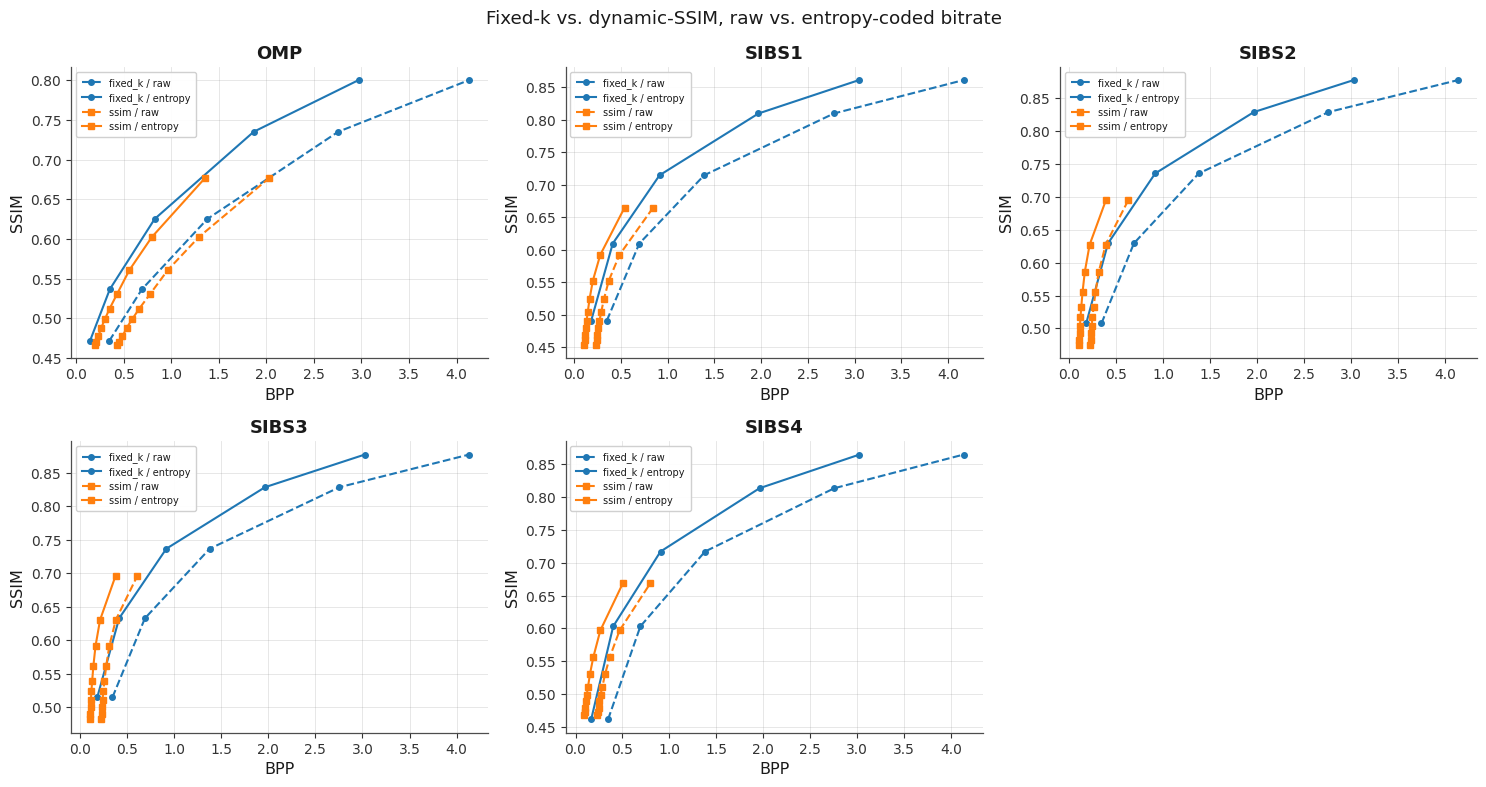


Saved comparison figure -> /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/comparison_suite_rd_curves.png

F-SIBS VARIANTS vs. JPEG / JPEG2000 -- k & SSIM, raw vs. entropy-coded


F-SIBS variant comparison: 100% complete |██████████| 4/4 [02:45<00:00]



Mean quality/bitrate per (F-SIBS variant, coding), averaged over 16 node(s) of dino / dino_ring:
algorithm  coding  mean_SSIM  mean_avg_k  mean_BPP
 F-SIBS_1 entropy     0.5446      1.5974    0.2248
 F-SIBS_1     raw     0.5446      1.5974    0.3827
 F-SIBS_2 entropy     0.5562      1.3650    0.1865
 F-SIBS_2     raw     0.5562      1.3650    0.3270
 F-SIBS_3 entropy     0.5628      1.3610    0.1849
 F-SIBS_3     raw     0.5628      1.3610    0.3261
 F-SIBS_4 entropy     0.5022      1.5689    0.2047
 F-SIBS_4     raw     0.5022      1.5689    0.3759


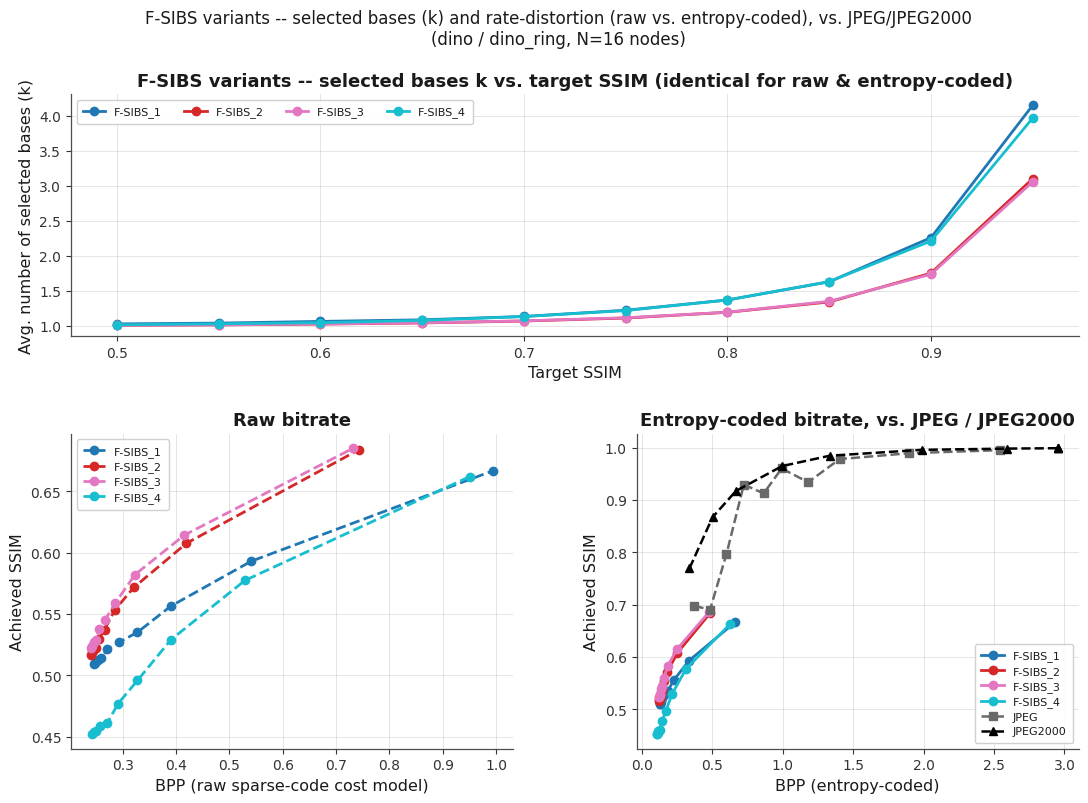


Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/fsibs_variant_comparison_results.csv and /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/fsibs_variant_k_ssim_comparison.png


In [7]:
# ============================================================
# Cell 42 (NEW) - Full comparison suite: summary report & plots
# ============================================================
if len(COMPARISON_RESULTS_DF) == 0:
    print("Skipped: comparison suite produced no rows (see Cell 41 for why).")
else:
    _BAR = "=" * 70
    print(_BAR)
    print("DYNAMIC-SSIM & FULL COMPARISON SUITE -- SUMMARY")
    print(_BAR)
    print("SSIM target sweep:", DYNAMIC_SSIM_TARGETS)
    print("Fixed-k grid:", COMPARISON_K_VALUES)
    print("Algorithms:", COMPARISON_ALGORITHMS)

    # ---- headline table: mean SSIM / BPP per algorithm x criterion x coding
    _pivot = (COMPARISON_RESULTS_DF
             .groupby(["algorithm", "stopping_criterion", "coding"])
             .agg(mean_SSIM=("SSIM", "mean"), mean_PSNR=("PSNR", "mean"),
                  mean_NMSE=("NMSE", "mean"), mean_avg_k=("avg_k", "mean"),
                  mean_BPP=("BPP", "mean"))
             .round(4).reset_index())
    print("\nMean quality/bitrate per (algorithm, stopping criterion, coding):")
    print(_pivot.to_string(index=False))

    # ---- entropy-coding gain: raw BPP vs entropy BPP, per algorithm/criterion
    _raw = COMPARISON_RESULTS_DF[COMPARISON_RESULTS_DF["coding"] == "raw"]
    _ent = COMPARISON_RESULTS_DF[COMPARISON_RESULTS_DF["coding"] == "entropy"]
    _merge_keys = ["dataset", "node", "algorithm", "stopping_criterion", "k_or_target"]
    _gain = _raw.merge(_ent, on=_merge_keys, suffixes=("_raw", "_entropy"))
    _gain["gain_pct"] = 100.0 * (1.0 - _gain["BPP_entropy"] / _gain["BPP_raw"])
    _gain_summary = (_gain.groupby(["algorithm", "stopping_criterion"])["gain_pct"]
                    .mean().round(2).reset_index())
    print("\nMean entropy-coding bitrate reduction (%) vs. the raw cost model, "
          "per algorithm and stopping criterion:")
    print(_gain_summary.to_string(index=False))

    # ---- fixed-k vs dynamic-SSIM, entropy-coded, per algorithm ----------
    print("\nFixed-k vs. dynamic-SSIM, ENTROPY-CODED bitrate, per algorithm "
          "(quality-matched: closest fixed-k SSIM to each algorithm's mean "
          "achieved dynamic-SSIM quality):")
    _ent_fixed = _ent[_ent["stopping_criterion"] == "fixed_k"]
    _ent_dyn = _ent[_ent["stopping_criterion"] == "ssim"]
    for _alg in COMPARISON_ALGORITHMS:
        _dyn_rows = _ent_dyn[_ent_dyn["algorithm"] == _alg]
        _fix_rows = _ent_fixed[_ent_fixed["algorithm"] == _alg]
        if len(_dyn_rows) == 0 or len(_fix_rows) == 0:
            continue
        for _target in COMPARISON_SSIM_TARGETS:
            _d = _dyn_rows[_dyn_rows["k_or_target"] == _target]
            if len(_d) == 0:
                continue
            _dyn_ssim = _d["SSIM"].mean(); _dyn_bpp = _d["BPP"].mean()
            _fix_agg = _fix_rows.groupby("k_or_target").agg(
                SSIM=("SSIM", "mean"), BPP=("BPP", "mean")).reset_index()
            _closest = _fix_agg.iloc[(_fix_agg["SSIM"] - _dyn_ssim).abs().argsort().iloc[0]]
            print("  %-6s target=%.2f | dynamic: SSIM=%.4f BPP=%.4f  |  "
                  "closest fixed-k=%d: SSIM=%.4f BPP=%.4f" % (
                      _alg, _target, _dyn_ssim, _dyn_bpp,
                      int(_closest["k_or_target"]), _closest["SSIM"], _closest["BPP"]))

    # ---- RD-curve plot: one panel per algorithm, 4 lines (criterion x coding)
    _algs_present = [a for a in COMPARISON_ALGORITHMS
                     if a in COMPARISON_RESULTS_DF["algorithm"].unique()]
    if _algs_present:
        _ncols = min(3, len(_algs_present))
        _nrows = int(np.ceil(len(_algs_present) / _ncols))
        fig, axes = plt.subplots(_nrows, _ncols, figsize=(5 * _ncols, 4 * _nrows), squeeze=False)
        _style = {("fixed_k", "raw"): ("o--", "tab:blue"),
                  ("fixed_k", "entropy"): ("o-", "tab:blue"),
                  ("ssim", "raw"): ("s--", "tab:orange"),
                  ("ssim", "entropy"): ("s-", "tab:orange")}
        for _i, _alg in enumerate(_algs_present):
            ax = axes[_i // _ncols][_i % _ncols]
            _sub = COMPARISON_RESULTS_DF[COMPARISON_RESULTS_DF["algorithm"] == _alg]
            for (_crit, _cod), (_ls, _color) in _style.items():
                _rows = (_sub[(_sub["stopping_criterion"] == _crit) & (_sub["coding"] == _cod)]
                        .groupby("k_or_target").agg(SSIM=("SSIM", "mean"), BPP=("BPP", "mean"))
                        .reset_index().sort_values("BPP"))
                if len(_rows) == 0:
                    continue
                ax.plot(_rows["BPP"], _rows["SSIM"], _ls, color=_color,
                       label="%s / %s" % (_crit, _cod), markersize=4)
            ax.set_title(_alg); ax.set_xlabel("BPP"); ax.set_ylabel("SSIM")
            ax.legend(fontsize=7)
        for _j in range(len(_algs_present), _nrows * _ncols):
            axes[_j // _ncols][_j % _ncols].axis("off")
        fig.suptitle("Fixed-k vs. dynamic-SSIM, raw vs. entropy-coded bitrate")
        fig.tight_layout()
        _fig_path = os.path.join(FIG_DIR, "comparison_suite_rd_curves.png")
        fig.savefig(_fig_path); plt.show()
        print("\nSaved comparison figure ->", _fig_path)

    # ============================================================
    # NEW ADDITION - F-SIBS variants (k & SSIM, raw vs. entropy-coded)
    #   + JPEG/JPEG2000 baselines, in their own dedicated figure.
    #   Everything above this point (COMPARISON_RESULTS_DF, the headline
    #   table, the entropy-coding-gain summary, the fixed-k-vs-dynamic-SSIM
    #   printout, and the original OMP/SIBS1-4 comparison_suite_rd_curves.png
    #   figure) is UNCHANGED. This block only reads shared globals that
    #   already exist by this point in the notebook (CONV_SPECS, Cell 19;
    #   ACTIVE_F_SIBS_VARIANTS/F_SIBS_VARIANT_TO_SIBS, Cell 8/9; the
    #   dynamic-SSIM/entropy-coding helpers, Cell 40; jpeg_encode_decode/
    #   jpeg2000_encode_decode, Cell 9c/9) and writes only new,
    #   separately-named variables (FSIBS_COMPARISON_DF, FSIBS_JPEG_RD,
    #   FSIBS_J2K_RD) - it never touches COMPARISON_RESULTS_DF or any
    #   other existing structure.
    #
    #   Design note (why F-SIBS needs its own run rather than reusing
    #   COMPARISON_RESULTS_DF): the local suite above only ever encodes
    #   against the STATIC per-node dictionary Phi (Cell 8's scope note).
    #   F-SIBS's whole point is the FEDERATED dictionary, so here each
    #   variant is first run to convergence via f_sibs_simulate (Cell 9,
    #   unmodified, same K_SUMMARY/K_GLOBAL/N_ROUNDS_FULL/tau=0.95 defaults
    #   used everywhere else in this notebook) to obtain its global_dict;
    #   every node is then RE-ENCODED with the exact same dynamic-SSIM
    #   stopping rule as the local suite above (_run_algorithm_generic +
    #   _encode_column_dynamic_ssim, unmodified), but over the AUGMENTED
    #   dictionary [Phi, global_dict] - i.e. the same per-column encoder,
    #   just handed the federated dictionary instead of the local-only one.
    # ============================================================
    print("\n" + _BAR)
    print("F-SIBS VARIANTS vs. JPEG / JPEG2000 -- k & SSIM, raw vs. entropy-coded")
    print(_BAR)

    if not CONV_SPECS:
        print("Skipped: no federated node group available in this run (see Cell 19).")
    elif not ACTIVE_F_SIBS_VARIANTS:
        print("Skipped: no F-SIBS variant is selected in this run (see Cell 0/8).")
    else:
        _ds_fc, _cfg_fc, _gi_fc = CONV_SPECS[0]
        _group_fc = GROUPS[_cfg_fc][_gi_fc]
        _imgs_fc = [POOLS[_ds_fc][i]["img"] for i in _group_fc["node_idx"]]
        _Phi_fc = PHI[_ds_fc]
        _h_fc, _w_fc = GEOMETRY[_ds_fc]
        _n_px_fc = _h_fc * _w_fc
        _N_nodes_fc = len(_imgs_fc)

        FSIBS_COMPARISON_ROWS = []
        for _vname_fc, _vfn_fc in tqdm(ACTIVE_F_SIBS_VARIANTS.items(),
                                       desc="F-SIBS variant comparison", bar_format=PBAR_FORMAT):
            _fed_fc = _vfn_fc(_imgs_fc, _Phi_fc, DELTA, K_SUMMARY, K_global=K_GLOBAL,
                              n_rounds=N_ROUNDS_FULL, tau=0.95, eps_conv=EPS_CONV, seed=42)
            _Psi_fc = _fed_fc["global_dict"]
            if _Psi_fc.shape[1] > 0:
                _Phi_aug_fc = np.column_stack([_Phi_fc, _Psi_fc])
                _nrm_fc = np.linalg.norm(_Phi_aug_fc, axis=0, keepdims=True)
                _nrm_fc[_nrm_fc < 1e-12] = 1.0
                _Phi_aug_fc = _Phi_aug_fc / _nrm_fc
            else:
                _Phi_aug_fc = _Phi_fc
            _N_dict_fc = _Phi_aug_fc.shape[1]
            _alg_fc = F_SIBS_VARIANT_TO_SIBS.get(_vname_fc, "SIBS1")

            for _target_fc in DYNAMIC_SSIM_TARGETS:
                _ssims_fc, _ks_fc, _raw_bits_fc, _ent_bits_fc = [], [], [], []
                for _X_fc in _imgs_fc:
                    _Xh_fc, _K_fc, _idx_fc, _coef_fc = _run_algorithm_generic(
                        _alg_fc, _X_fc, _Phi_aug_fc, DELTA,
                        lambda xo, et, ph, off, _t=_target_fc: _encode_column_dynamic_ssim(
                            xo, et, ph, off, _t, DYNAMIC_SSIM_K_MAX))
                    _Xh_fc = np.clip(_Xh_fc, 0, 255)
                    _enc_fc = entropy_code_sparse_representation(
                        _idx_fc, _coef_fc, list(_K_fc), _N_dict_fc, bits_coeff=DYNAMIC_SSIM_BITS_COEFF)
                    _ssims_fc.append(ssim(_X_fc, _Xh_fc))
                    _ks_fc.append(float(np.mean(_K_fc)))
                    _raw_bits_fc.append(_enc_fc["raw_bits"])
                    _ent_bits_fc.append(_enc_fc["entropy_bits"])

                _mean_ssim_fc = float(np.mean(_ssims_fc))
                _mean_k_fc = float(np.mean(_ks_fc))
                for _coding_fc, _bits_list_fc in (("raw", _raw_bits_fc), ("entropy", _ent_bits_fc)):
                    FSIBS_COMPARISON_ROWS.append({
                        "algorithm": _vname_fc, "stopping_criterion": "ssim", "coding": _coding_fc,
                        "k_or_target": _target_fc, "avg_k": _mean_k_fc, "SSIM": _mean_ssim_fc,
                        "BPP": float(np.mean(_bits_list_fc)) / _n_px_fc,
                    })

        FSIBS_COMPARISON_DF = pd.DataFrame(FSIBS_COMPARISON_ROWS)
        _fc_csv = os.path.join(FIG_DIR, "fsibs_variant_comparison_results.csv")
        FSIBS_COMPARISON_DF.to_csv(_fc_csv, index=False)

        # ---- JPEG / JPEG2000 baselines, same node group/images, same
        #      (unmodified) codec functions used everywhere else -----------
        _jpeg_rows_fc, _j2k_rows_fc = [], []
        for _X_fc in _imgs_fc:
            for _q_fc in JPEG_QUALITIES:
                _Xh_fc, _bpp_fc = jpeg_encode_decode(_X_fc, _q_fc)
                _jpeg_rows_fc.append({"rate": _q_fc, "BPP": _bpp_fc, "SSIM": ssim(_X_fc, _Xh_fc)})
            for _r_fc in J2K_RATES:
                _Xh_fc, _bpp_fc = jpeg2000_encode_decode(_X_fc, _r_fc)
                _j2k_rows_fc.append({"rate": _r_fc, "BPP": _bpp_fc, "SSIM": ssim(_X_fc, _Xh_fc)})
        FSIBS_JPEG_RD = pd.DataFrame(_jpeg_rows_fc).groupby("rate").agg(
            BPP=("BPP", "mean"), SSIM=("SSIM", "mean")).reset_index().sort_values("BPP")
        FSIBS_J2K_RD = pd.DataFrame(_j2k_rows_fc).groupby("rate").agg(
            BPP=("BPP", "mean"), SSIM=("SSIM", "mean")).reset_index().sort_values("BPP")

        print("\nMean quality/bitrate per (F-SIBS variant, coding), averaged over "
              "%d node(s) of %s / %s:" % (_N_nodes_fc, _ds_fc, _cfg_fc))
        print(FSIBS_COMPARISON_DF.groupby(["algorithm", "coding"]).agg(
            mean_SSIM=("SSIM", "mean"), mean_avg_k=("avg_k", "mean"),
            mean_BPP=("BPP", "mean")).round(4).reset_index().to_string(index=False))

        # ---- figure: 1 wide "k" panel on top + 2 R-D panels (raw / entropy) below
        _variants_present = [v for v in ACTIVE_F_SIBS_VARIANTS
                             if v in FSIBS_COMPARISON_DF["algorithm"].unique()]
        _variant_colors = dict(zip(_variants_present,
                                   plt.cm.tab10(np.linspace(0, 1, max(len(_variants_present), 1)))))

        fig = plt.figure(figsize=(13, 8.5))
        gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3], hspace=0.35, wspace=0.28)
        ax_k = fig.add_subplot(gs[0, :])
        ax_raw = fig.add_subplot(gs[1, 0])
        ax_ent = fig.add_subplot(gs[1, 1])

        # Panel 1: avg_k vs. target SSIM (coding-invariant -- k is fixed
        # before entropy coding is ever applied, so raw and entropy rows
        # share the same avg_k by construction; plotted once per variant).
        for _v in _variants_present:
            _sub_k = (FSIBS_COMPARISON_DF[(FSIBS_COMPARISON_DF["algorithm"] == _v)
                     & (FSIBS_COMPARISON_DF["coding"] == "entropy")]
                     .sort_values("k_or_target"))
            ax_k.plot(_sub_k["k_or_target"], _sub_k["avg_k"], "o-",
                     color=_variant_colors[_v], lw=2, markersize=6, label=_v)
        ax_k.set_xlabel("Target SSIM"); ax_k.set_ylabel("Avg. number of selected bases (k)")
        ax_k.set_title("F-SIBS variants -- selected bases k vs. target SSIM "
                       "(identical for raw & entropy-coded)")
        ax_k.legend(fontsize=8, ncol=len(_variants_present)); ax_k.grid(True, alpha=0.3)

        # Panels 2/3: SSIM vs. BPP, raw and entropy-coded shown SEPARATELY.
        # JPEG/JPEG2000 file sizes are already real, entropy-coded
        # bitstreams (there is no meaningful "raw JPEG" bitrate), so the
        # baselines are shown only in the entropy-coded panel -- the panel
        # that is actually comparable to a delivered, compressed file.
        for _v in _variants_present:
            _sub_raw = (FSIBS_COMPARISON_DF[(FSIBS_COMPARISON_DF["algorithm"] == _v)
                       & (FSIBS_COMPARISON_DF["coding"] == "raw")].sort_values("BPP"))
            ax_raw.plot(_sub_raw["BPP"], _sub_raw["SSIM"], "o--",
                       color=_variant_colors[_v], lw=2, markersize=6, label=_v)
        ax_raw.set_xlabel("BPP (raw sparse-code cost model)"); ax_raw.set_ylabel("Achieved SSIM")
        ax_raw.set_title("Raw bitrate")
        ax_raw.legend(fontsize=8); ax_raw.grid(True, alpha=0.3)

        for _v in _variants_present:
            _sub_ent = (FSIBS_COMPARISON_DF[(FSIBS_COMPARISON_DF["algorithm"] == _v)
                       & (FSIBS_COMPARISON_DF["coding"] == "entropy")].sort_values("BPP"))
            ax_ent.plot(_sub_ent["BPP"], _sub_ent["SSIM"], "o-",
                       color=_variant_colors[_v], lw=2, markersize=6, label=_v)
        ax_ent.plot(FSIBS_JPEG_RD["BPP"], FSIBS_JPEG_RD["SSIM"], "s--",
                   color="dimgray", lw=1.8, markersize=6, label="JPEG")
        ax_ent.plot(FSIBS_J2K_RD["BPP"], FSIBS_J2K_RD["SSIM"], "^--",
                   color="black", lw=1.8, markersize=6, label="JPEG2000")
        ax_ent.set_xlabel("BPP (entropy-coded)"); ax_ent.set_ylabel("Achieved SSIM")
        ax_ent.set_title("Entropy-coded bitrate, vs. JPEG / JPEG2000")
        ax_ent.legend(fontsize=8); ax_ent.grid(True, alpha=0.3)

        fig.suptitle("F-SIBS variants -- selected bases (k) and rate-distortion "
                    "(raw vs. entropy-coded), vs. JPEG/JPEG2000\n(%s / %s, N=%d nodes)"
                    % (_ds_fc, _cfg_fc, _N_nodes_fc), fontsize=12)
        _fc_fig_path = os.path.join(FIG_DIR, "fsibs_variant_k_ssim_comparison.png")
        fig.savefig(_fc_fig_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("\nSaved:", _fc_csv, "and", _fc_fig_path)
    print(_BAR)


Bjontegaard BD-rate (negative = F-SIBS needs LESS rate than the anchor for equal SSIM):
                       method   anchor  BD_rate_pct                                                     note
                     F-SIBS_1     JPEG          NaN SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
                     F-SIBS_1 JPEG2000          NaN SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
                     F-SIBS_2     JPEG          NaN SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
                     F-SIBS_2 JPEG2000          NaN SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
                     F-SIBS_3     JPEG          NaN SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
                     F-SIBS_3 JPEG2000          NaN SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
                     F-SIBS_4     JPEG          NaN SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
                     F-SIBS_4 JPEG2000 

method,anchor,BD_rate_pct,note
F-SIBS_1,JPEG,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
F-SIBS_1,JPEG2000,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
F-SIBS_2,JPEG,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
F-SIBS_2,JPEG2000,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
F-SIBS_3,JPEG,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
F-SIBS_3,JPEG2000,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
F-SIBS_4,JPEG,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
F-SIBS_4,JPEG2000,—,SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)
"OMP (dynamic-SSIM, entropy)",JPEG,-32.76,SSIM-based BD-rate
"OMP (dynamic-SSIM, entropy)",JPEG2000,-26.27,SSIM-based BD-rate


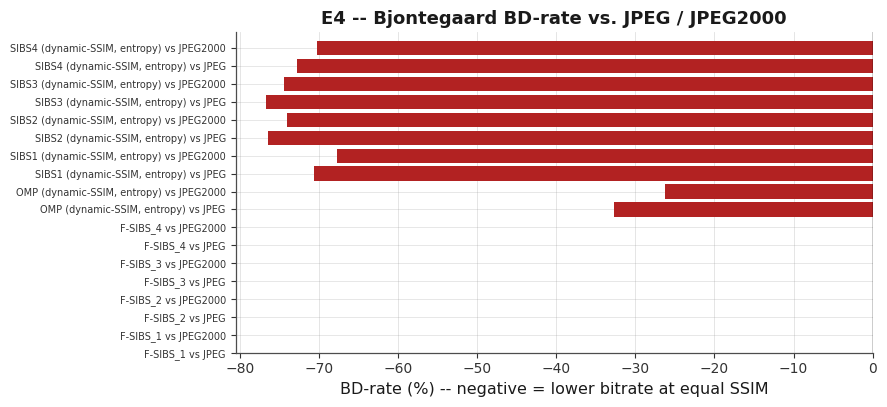

In [9]:
# ============================================================
# V3.2 E4 ADDITION (additive only): Bjontegaard BD-rate / BD-PSNR of the
# entropy-coded F-SIBS variants (and of the local dynamic-SSIM suite)
# against the JPEG and JPEG2000 anchors measured on the SAME node group
# above. Uses the new bd_rate()/bd_psnr() helpers (Cell 2). The R-D
# points themselves are unchanged.
# ============================================================
try:
    if ("FSIBS_COMPARISON_DF" in dir() and len(FSIBS_COMPARISON_DF) > 0
            and "FSIBS_JPEG_RD" in dir() and len(FSIBS_JPEG_RD) >= 3
            and "FSIBS_J2K_RD" in dir() and len(FSIBS_J2K_RD) >= 3):
        _anchor_jpeg = (FSIBS_JPEG_RD["BPP"].to_numpy(), FSIBS_JPEG_RD["SSIM"].to_numpy())
        _anchor_j2k = (FSIBS_J2K_RD["BPP"].to_numpy(), FSIBS_J2K_RD["SSIM"].to_numpy())
        _bd_rows = []
        for _bdv in ACTIVE_F_SIBS_VARIANTS:
            _sub = (FSIBS_COMPARISON_DF[(FSIBS_COMPARISON_DF["algorithm"] == _bdv) &
                                        (FSIBS_COMPARISON_DF["coding"] == "entropy")]
                    .sort_values("BPP"))
            if len(_sub) < 3:
                continue
            for _anc_name, _anc in (("JPEG", _anchor_jpeg), ("JPEG2000", _anchor_j2k)):
                _bd_rows.append({
                    "method": _bdv, "anchor": _anc_name,
                    "BD_rate_pct": bd_rate(_anc[0], _anc[1],
                                           _sub["BPP"].to_numpy(), _sub["SSIM"].to_numpy()),
                    "note": "SSIM-based BD-rate (PSNR anchor n/a for SSIM-domain fit)",
                })
        # local algorithms from the comparison suite (dynamic-SSIM, entropy-coded)
        if "COMPARISON_RESULTS_DF" in dir() and len(COMPARISON_RESULTS_DF) > 0:
            _cmp_ent = COMPARISON_RESULTS_DF[(COMPARISON_RESULTS_DF["coding"] == "entropy") &
                                             (COMPARISON_RESULTS_DF["stopping_criterion"] == "ssim")]
            for _algname in COMPARISON_ALGORITHMS:
                _agg = (_cmp_ent[_cmp_ent["algorithm"] == _algname]
                        .groupby("BPP").agg(SSIM=("SSIM", "mean")).reset_index().sort_values("BPP"))
                if len(_agg) < 3:
                    continue
                for _anc_name, _anc in (("JPEG", _anchor_jpeg), ("JPEG2000", _anchor_j2k)):
                    _bd_rows.append({
                        "method": "%s (dynamic-SSIM, entropy)" % _algname, "anchor": _anc_name,
                        "BD_rate_pct": bd_rate(_anc[0], _anc[1],
                                               _agg["BPP"].to_numpy(), _agg["SSIM"].to_numpy()),
                        "note": "SSIM-based BD-rate",
                    })
        BD_RATE_DF = pd.DataFrame(_bd_rows)
        if len(BD_RATE_DF):
            print("\nBjontegaard BD-rate (negative = F-SIBS needs LESS rate than the "
                  "anchor for equal SSIM):")
            print(BD_RATE_DF.round(3).to_string(index=False))
            save_table(BD_RATE_DF, 4, "exp4_bd_rate_vs_jpeg_jpeg2000")
            EXPERIMENT_MANIFEST[4]["tables"].append("exp4_bd_rate_vs_jpeg_jpeg2000.csv")
            fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
            _lbls = ["%s vs %s" % (r["method"], r["anchor"]) for _, r in BD_RATE_DF.iterrows()]
            _vals = BD_RATE_DF["BD_rate_pct"].to_numpy(dtype=float)
            _cols = ["#b22222" if v < 0 else "#888888" for v in _vals]
            ax.barh(range(len(_vals)), _vals, color=_cols)
            ax.set_yticks(range(len(_vals))); ax.set_yticklabels(_lbls, fontsize=7)
            ax.axvline(0, color="k", lw=1)
            ax.set_xlabel("BD-rate (%) -- negative = lower bitrate at equal SSIM")
            ax.set_title("E4 -- Bjontegaard BD-rate vs. JPEG / JPEG2000")
            ax.grid(axis="x", alpha=0.3)
            plt.tight_layout()
            save_figure(fig, 4, "exp4_bd_rate_bars")
            plt.show()
            EXPERIMENT_MANIFEST[4]["figures"].append("exp4_bd_rate_bars.png")
        else:
            print("BD-rate skipped: fewer than 3 common R-D points.")
    else:
        print("Skipped: BD-rate -- F-SIBS comparison R-D or codec anchors missing "
              "(federated group not available).")
except Exception as _e4bd:
    print("BD-rate computation deferred:", repr(_e4bd))

Experiment 4 (completion): federated R-D curve on dino / dino_ring (variant F-SIBS_1, local encoder SIBS1, N=16 nodes)


Exp.4 dynamic-SSIM sweep: 100% complete |██████████| 10/10 [00:09<00:00]



Experiment 4 (completion) -- federated entropy-coded R-D table (BPP and compression ratio averaged over 16 images):
                            method  target_SSIM  achieved_SSIM  avg_k  coefficient_BPP_entropy_coded  federated_communication_BPP  total_BPP_entropy_coded  compression_ratio
F-SIBS_1 (federated, dynamic-SSIM)         0.50         0.5095 1.0273                         0.1266                       4.7496                   4.8762             1.6406
F-SIBS_1 (federated, dynamic-SSIM)         0.55         0.5100 1.0386                         0.1287                       4.7496                   4.8783             1.6399
F-SIBS_1 (federated, dynamic-SSIM)         0.60         0.5126 1.0630                         0.1329                       4.7496                   4.8825             1.6385
F-SIBS_1 (federated, dynamic-SSIM)         0.65         0.5142 1.0854                         0.1370                       4.7496                   4.8866             1.6371
F-SIBS_1 (fed

method,target_SSIM,achieved_SSIM,avg_k,coefficient_BPP_entropy_coded,federated_communication_BPP,total_BPP_entropy_coded,compression_ratio
"F-SIBS_1 (federated, dynamic-SSIM)",0.5,0.5095,1.027,0.1266,4.75,4.876,1.641
"F-SIBS_1 (federated, dynamic-SSIM)",0.55,0.51,1.039,0.1287,4.75,4.878,1.64
"F-SIBS_1 (federated, dynamic-SSIM)",0.6,0.5126,1.063,0.1329,4.75,4.883,1.638
"F-SIBS_1 (federated, dynamic-SSIM)",0.65,0.5142,1.085,0.137,4.75,4.887,1.637
"F-SIBS_1 (federated, dynamic-SSIM)",0.7,0.5212,1.133,0.1452,4.75,4.895,1.634
"F-SIBS_1 (federated, dynamic-SSIM)",0.75,0.5269,1.222,0.1602,4.75,4.91,1.629
"F-SIBS_1 (federated, dynamic-SSIM)",0.8,0.5352,1.369,0.1852,4.75,4.935,1.621
"F-SIBS_1 (federated, dynamic-SSIM)",0.85,0.5564,1.628,0.2298,4.75,4.979,1.607
"F-SIBS_1 (federated, dynamic-SSIM)",0.9,0.5931,2.258,0.3368,4.75,5.086,1.573
"F-SIBS_1 (federated, dynamic-SSIM)",0.95,0.6668,4.148,0.6653,4.75,5.415,1.477


rate,BPP,SSIM,compression_ratio
3,0.3744,0.6976,21.37
8,0.4849,0.6902,16.5
15,0.6012,0.7962,13.31
25,0.7248,0.9294,11.04
40,0.8656,0.9126,9.242
55,0.9933,0.9602,8.054
70,1.181,0.934,6.772
80,1.404,0.9781,5.696
90,1.897,0.9894,4.217
95,2.543,0.9953,3.146


rate,BPP,SSIM,compression_ratio
24,0.3392,0.7693,23.59
16,0.5027,0.8669,15.91
12,0.669,0.9173,11.96
8,0.9972,0.9649,8.023
6,1.335,0.9846,5.993
4,1.988,0.9959,4.024
3,2.593,0.9982,3.085
2,2.957,0.999,2.705
1.5,2.957,0.999,2.705
1.2,2.957,0.999,2.705



Average compression achieved (entropy-coded BPP -> compression ratio vs. an uncompressed 8-bit/pixel image, averaged over 16 images and over the full dynamic-SSIM/quality/rate sweep):
                             method  n_images_averaged  avg_BPP  avg_compression_ratio
F-SIBS_1 (federated, entropy-coded)                 16    4.974                  1.610
                               JPEG                 16    1.107                  9.934
                           JPEG2000                 16    1.730                  8.070


method,n_images_averaged,avg_BPP,avg_compression_ratio
"F-SIBS_1 (federated, entropy-coded)",16,4.974,1.61
JPEG,16,1.107,9.934
JPEG2000,16,1.73,8.07


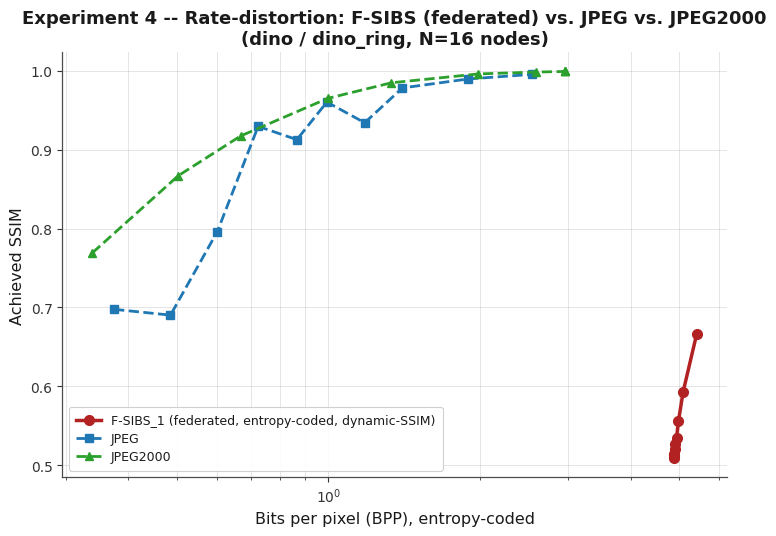


Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_federated_rd_table.csv and /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_federated_rd_curve.png and /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_avg_compression_ratio.csv
Federated communication BPP (amortised, constant across the SSIM sweep at this node group/tau): 4.74961 bpp/node


In [10]:
# ============================================================
# Cell 52 (NEW) - Completing Experiment 4: Federated Compression &
#   Rate-Distortion Analysis. Section 10 (Cells 39-42) already built the
#   dynamic-SSIM / entropy-coding pipeline for the LOCAL, single-node
#   algorithms only (OMP, SIBS1-4) and never touched federation or the
#   JPEG/JPEG2000 baselines. This cell closes both gaps:
#     1. runs F-SIBS once (fixed k=K_SUMMARY, tau=0.95, the notebook's
#        standard federation settings) to obtain the global dictionary
#        AND the entropy-coded uplink cost (same convention as §12 Exp.6);
#     2. re-encodes every node with the SAME dynamic-SSIM machinery as
#        §10 (_run_algorithm_generic + _encode_column_dynamic_ssim,
#        UNCHANGED), but over the AUGMENTED dictionary [Phi, global_dict]
#        - i.e. each node's local reconstruction now benefits from the
#        federated bases, exactly as F-SIBS's own final reconstruction
#        pass already does in f_sibs_simulate (Cell 9);
#     3. reports coefficient BPP, federated communication BPP (uplink
#        bits amortised over every node/pixel) and total BPP separately,
#        all entropy-coded (never the raw bpp_sparse cost model);
#     4. overlays the result with genuine JPEG (Cell 9c) and JPEG2000
#        (Cell 9) rate-distortion curves on the SAME axes.
# ============================================================
if "_ds6" not in globals() or _ds6 is None:
    print("Skipped: Experiment 4 completion (federated R-D curve) -- no "
          "federated node group is available in this run.")
else:
    _vname4, _vfn4 = next(iter(ACTIVE_F_SIBS_VARIANTS.items()))
    _alg4 = F_SIBS_VARIANT_TO_SIBS.get(_vname4, "SIBS1")
    _h4, _w4 = GEOMETRY[_ds6] if _ds6 in GEOMETRY else _imgs6[0].shape
    _n_px4 = _h4 * _w4
    _N_nodes4 = len(_imgs6)

    print("Experiment 4 (completion): federated R-D curve on %s / %s "
          "(variant %s, local encoder %s, N=%d nodes)"
          % (_ds6, _cfg6, _vname4, _alg4, _N_nodes4))

    # ---- 1) federation run: global dictionary + entropy-coded uplink cost ----
    _fed4 = _vfn4(_imgs6, PHI[_ds6], DELTA, K_SUMMARY, K_global=K_GLOBAL,
                 n_rounds=N_ROUNDS_FULL, tau=0.95, eps_conv=EPS_CONV, seed=42,
                 return_transmitted_vectors=True)
    _all_vecs4 = np.concatenate(
        [v for v in _fed4["transmitted_vectors_history"] if v.shape[1] > 0], axis=1
    ) if sum(v.shape[1] for v in _fed4["transmitted_vectors_history"]) > 0 else np.zeros((_h4, 0))
    if _all_vecs4.shape[1] > 0:
        _q4, _ = quantize_coeffs(_all_vecs4.ravel(), bits=DYNAMIC_SSIM_BITS_COEFF)
        _uplink_entropy_bits = float(_entropy_bits_per_symbol(_q4) * _all_vecs4.size)
    else:
        _uplink_entropy_bits = 0.0
    # amortised per (node, pixel): total federated uplink bits / (N_nodes * pixels/node)
    _federated_comm_bpp = _uplink_entropy_bits / (_N_nodes4 * _n_px4)

    Psi_g = _fed4["global_dict"]
    if Psi_g.shape[1] > 0:
        _Phi_aug4 = np.column_stack([PHI[_ds6], Psi_g])
        _nrm4 = np.linalg.norm(_Phi_aug4, axis=0, keepdims=True); _nrm4[_nrm4 < 1e-12] = 1.0
        _Phi_aug4 = _Phi_aug4 / _nrm4
    else:
        _Phi_aug4 = PHI[_ds6]
    _N_dict4 = _Phi_aug4.shape[1]

    # ---- 2) dynamic-SSIM re-encoding of every node over the augmented dict ----
    EXP4_ROWS = []
    for _target in tqdm(DYNAMIC_SSIM_TARGETS, desc="Exp.4 dynamic-SSIM sweep",
                        bar_format=PBAR_FORMAT):
        _coef_bpps, _achieved_ssims, _avg_ks = [], [], []
        for _X in _imgs6:
            _Xh, _K, _idx, _coef = _run_algorithm_generic(
                _alg4, _X, _Phi_aug4, DELTA,
                lambda xo, et, ph, off, _t=_target: _encode_column_dynamic_ssim(
                    xo, et, ph, off, _t, DYNAMIC_SSIM_K_MAX))
            _Xh = np.clip(_Xh, 0, 255)
            _enc4 = entropy_code_sparse_representation(_idx, _coef, list(_K), _N_dict4,
                                                       bits_coeff=DYNAMIC_SSIM_BITS_COEFF)
            _coef_bpps.append(_enc4["entropy_bits"] / _n_px4)
            _achieved_ssims.append(ssim(_X, _Xh))
            _avg_ks.append(float(np.mean(_K)))

        _coef_bpp = float(np.mean(_coef_bpps))
        _total_bpp = _coef_bpp + _federated_comm_bpp
        EXP4_ROWS.append({
            "method": "%s (federated, dynamic-SSIM)" % _vname4,
            "target_SSIM": _target,
            "achieved_SSIM": float(np.mean(_achieved_ssims)),
            "avg_k": float(np.mean(_avg_ks)),
            "coefficient_BPP_entropy_coded": _coef_bpp,
            "federated_communication_BPP": _federated_comm_bpp,
            "total_BPP_entropy_coded": _total_bpp,
        })

    # RAW_BITS_PER_PIXEL: uncompressed reference used to turn BPP into a
    # human-readable "compression ratio" (X:1). 8-bit grayscale source, as
    # used throughout this notebook's node images.
    RAW_BITS_PER_PIXEL = 8.0
    EXP4_DF = pd.DataFrame(EXP4_ROWS)
    EXP4_DF["compression_ratio"] = RAW_BITS_PER_PIXEL / EXP4_DF["total_BPP_entropy_coded"]

    # ---- 3) JPEG / JPEG2000 baselines on the same node group, same images ----
    #      (per-image BPP/SSIM are averaged across every image in _imgs6 at
    #      each quality/rate -- identical "average across several images"
    #      convention as the F-SIBS loop above.)
    _jpeg_rows, _j2k_rows = [], []
    for _X in _imgs6:
        for _q in JPEG_QUALITIES:
            _Xh, _bpp = jpeg_encode_decode(_X, _q)
            _jpeg_rows.append({"rate": _q, "BPP": _bpp, "SSIM": ssim(_X, _Xh)})
        for _r in J2K_RATES:
            _Xh, _bpp = jpeg2000_encode_decode(_X, _r)
            _j2k_rows.append({"rate": _r, "BPP": _bpp, "SSIM": ssim(_X, _Xh)})
    JPEG_RD = pd.DataFrame(_jpeg_rows).groupby("rate").agg(
        BPP=("BPP", "mean"), SSIM=("SSIM", "mean")).reset_index().sort_values("BPP")
    J2K_RD = pd.DataFrame(_j2k_rows).groupby("rate").agg(
        BPP=("BPP", "mean"), SSIM=("SSIM", "mean")).reset_index().sort_values("BPP")
    JPEG_RD["compression_ratio"] = RAW_BITS_PER_PIXEL / JPEG_RD["BPP"]
    J2K_RD["compression_ratio"] = RAW_BITS_PER_PIXEL / J2K_RD["BPP"]

    print("\nExperiment 4 (completion) -- federated entropy-coded R-D table "
          "(BPP and compression ratio averaged over %d images):" % _N_nodes4)
    print(EXP4_DF.round(4).to_string(index=False))
    _exp4_table_path = save_table(EXP4_DF, 4, "exp4_federated_rd_table")
    save_table(JPEG_RD, 4, "exp4_jpeg_baseline_rd")
    save_table(J2K_RD, 4, "exp4_jpeg2000_baseline_rd")

    # ---- average compression achieved by the selected F-SIBS variant, ----
    # ---- entropy-coded, across all N images and across the whole      ----
    # ---- dynamic-SSIM sweep -- plus the matching JPEG/JPEG2000 numbers ----
    # ---- for a direct side-by-side comparison.                        ----
    EXP4_COMPRESSION_SUMMARY = pd.DataFrame([
        {"method": "%s (federated, entropy-coded)" % _vname4,
         "n_images_averaged": _N_nodes4,
         "avg_BPP": EXP4_DF["total_BPP_entropy_coded"].mean(),
         "avg_compression_ratio": EXP4_DF["compression_ratio"].mean()},
        {"method": "JPEG", "n_images_averaged": _N_nodes4,
         "avg_BPP": JPEG_RD["BPP"].mean(),
         "avg_compression_ratio": JPEG_RD["compression_ratio"].mean()},
        {"method": "JPEG2000", "n_images_averaged": _N_nodes4,
         "avg_BPP": J2K_RD["BPP"].mean(),
         "avg_compression_ratio": J2K_RD["compression_ratio"].mean()},
    ])
    print("\nAverage compression achieved (entropy-coded BPP -> compression ratio "
          "vs. an uncompressed %.0f-bit/pixel image, averaged over %d images and "
          "over the full dynamic-SSIM/quality/rate sweep):" % (RAW_BITS_PER_PIXEL, _N_nodes4))
    print(EXP4_COMPRESSION_SUMMARY.round(3).to_string(index=False))
    _exp4_compression_path = save_table(EXP4_COMPRESSION_SUMMARY, 4, "exp4_avg_compression_ratio")
    EXPERIMENT_MANIFEST[4]["tables"].append("exp4_avg_compression_ratio.csv")

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.plot(EXP4_DF["total_BPP_entropy_coded"], EXP4_DF["achieved_SSIM"],
           "o-", color="#b22222", lw=2.5, markersize=7,
           label="%s (federated, entropy-coded, dynamic-SSIM)" % _vname4)
    ax.plot(JPEG_RD["BPP"], JPEG_RD["SSIM"], "s--", color="#1f77b4", lw=2,
           markersize=6, label="JPEG")
    ax.plot(J2K_RD["BPP"], J2K_RD["SSIM"], "^--", color="#2ca02c", lw=2,
           markersize=6, label="JPEG2000")
    ax.set_xlabel("Bits per pixel (BPP), entropy-coded")
    ax.set_ylabel("Achieved SSIM")
    ax.set_xscale("log")
    ax.set_title("Experiment 4 -- Rate-distortion: F-SIBS (federated) vs. JPEG vs. JPEG2000\n"
                "(%s / %s, N=%d nodes)" % (_ds6, _cfg6, _N_nodes4))
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    _exp4_fig_path = save_figure(fig, 4, "exp4_federated_rd_curve")
    plt.show()

    EXPERIMENT_MANIFEST[4]["tables"].extend(
        ["exp4_federated_rd_table.csv", "exp4_jpeg_baseline_rd.csv", "exp4_jpeg2000_baseline_rd.csv"])
    EXPERIMENT_MANIFEST[4]["figures"].append("exp4_federated_rd_curve.png")
    print("\nSaved:", _exp4_table_path, "and", _exp4_fig_path, "and", _exp4_compression_path)
    print("Federated communication BPP (amortised, constant across the SSIM sweep at this "
          "node group/tau): %.5f bpp/node" % _federated_comm_bpp)

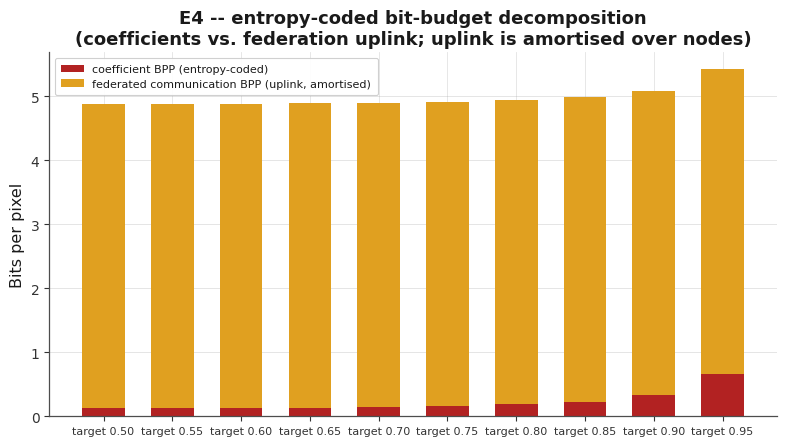

Experiment 4 EXTENSION -- config: N_RUNS=3, N fractions=[0.5, 1.0], tau sweep=[0.3, 0.6, 0.9, 0.95, 0.99], 10 dynamic-SSIM targets
Experiment 4 extension will run on 3 dataset(s): coil20 (coil20_same_object, group coil20_obj01, N_max=4), dino (dino_ring, group dino_ring, N_max=16), temple (temple_ring, group temple_ring, N_max=16)
Total (dataset, N, tau, run) configurations: 90 (x 10 dynamic-SSIM targets each)
90 of 90 configurations remaining after checkpoint skip.


Exp.4 extension sweep (1-50/90) (parallel, 96 workers): 100% complete |██████████| 50/50 [00:27<00:00]

  checkpoint saved: 500/900 rows -> /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/exp4_ext_multi_dataset_N_tau_raw_runs.csv



Exp.4 extension sweep (51-90/90) (parallel, 96 workers): 100% complete |██████████| 40/40 [00:31<00:00]


  checkpoint saved: 900/900 rows -> /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/fsibs_eval_outputs/exp4_ext_multi_dataset_N_tau_raw_runs.csv

Experiment 4 extension -- averaged R-D table (mean +/- std over 3 runs; showing first 15 of 300 rows):
dataset             config     group_id                             method  N_nodes  tau  target_SSIM  achieved_SSIM_mean  achieved_SSIM_std  avg_k_mean  avg_k_std  coefficient_BPP_entropy_coded_mean  coefficient_BPP_entropy_coded_std  federated_communication_BPP_mean  federated_communication_BPP_std  total_BPP_entropy_coded_mean  total_BPP_entropy_coded_std  compression_ratio_mean  compression_ratio_std  n_runs
 coil20 coil20_same_object coil20_obj01 F-SIBS_1 (federated, dynamic-SSIM)        2  0.3         0.50              0.6486             0.0056      1.0052     0.0023                              0.0885                             0.0003                            1.3851                              0.0                        1.4

dataset,config,group_id,method,N_nodes,tau,target_SSIM,achieved_SSIM_mean,achieved_SSIM_std,avg_k_mean,avg_k_std,coefficient_BPP_entropy_coded_mean,coefficient_BPP_entropy_coded_std,federated_communication_BPP_mean,federated_communication_BPP_std,total_BPP_entropy_coded_mean,total_BPP_entropy_coded_std,compression_ratio_mean,compression_ratio_std,n_runs
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.5,0.6486,0.00559,1.005,0.002255,0.08849,0.0002789,1.385,0,1.474,0.0002789,5.429,0.001028,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.55,0.6487,0.005603,1.007,0.002255,0.0887,0.0004942,1.385,0,1.474,0.0004942,5.428,0.00182,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.6,0.6487,0.005603,1.007,0.002255,0.0887,0.0004942,1.385,0,1.474,0.0004942,5.428,0.00182,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.65,0.6487,0.005421,1.01,0.002255,0.08912,0.0005014,1.385,0,1.474,0.0005014,5.427,0.001846,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.7,0.649,0.005334,1.017,0.008132,0.08997,0.0012,1.385,0,1.475,0.0012,5.424,0.004415,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.75,0.6491,0.006089,1.035,0.003906,0.09262,0.0005864,1.385,0,1.478,0.0005864,5.414,0.002148,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.8,0.6499,0.00519,1.055,0.007812,0.09507,0.0008921,1.385,0,1.48,0.0008921,5.405,0.003257,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.85,0.6517,0.004852,1.09,0.01353,0.09905,0.001805,1.385,0,1.484,0.001805,5.39,0.00656,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.9,0.6566,0.004305,1.167,0.01966,0.109,0.002462,1.385,0,1.494,0.002462,5.354,0.00882,3
coil20,coil20_same_object,coil20_obj01,"F-SIBS_1 (federated, dynamic-SSIM)",2,0.3,0.95,0.6834,0.004294,1.596,0.07855,0.1632,0.009868,1.385,0,1.548,0.009868,5.167,0.03287,3


dataset,method,n_images_averaged,avg_BPP,avg_compression_ratio
coil20,JPEG,4,0.894,8.949
coil20,JPEG2000,4,1.611,4.966
dino,JPEG,16,1.107,7.227
dino,JPEG2000,16,1.73,4.625
temple,JPEG,16,1.083,7.385
temple,JPEG2000,16,1.761,4.543



Experiment 4 extension -- summary averaged across the full dynamic-SSIM target sweep AND across runs, per (dataset, N, tau):
dataset  N_nodes  tau  avg_BPP  avg_compression_ratio  avg_achieved_SSIM  avg_k  n_runs
 coil20        2 0.30   1.4855                 5.3866             0.6534 1.0988       3
 coil20        2 0.60   1.4855                 5.3866             0.6534 1.0988       3
 coil20        2 0.90   1.5289                 5.2366             0.6510 1.0870       3
 coil20        2 0.95   1.5585                 5.1351             0.6515 1.0865       3
 coil20        2 0.99   2.0713                 3.8896             0.6339 1.1034       3
 coil20        4 0.30   1.6269                 4.9181             0.6217 1.1033       3
 coil20        4 0.60   1.6269                 4.9181             0.6217 1.1033       3
 coil20        4 0.90   1.6586                 4.8242             0.6179 1.0988       3
 coil20        4 0.95   1.6904                 4.7360             0.6140 1.0986   

dataset,N_nodes,tau,avg_BPP,avg_compression_ratio,avg_achieved_SSIM,avg_k,n_runs
coil20,2,0.3,1.485,5.387,0.6534,1.099,3
coil20,2,0.6,1.485,5.387,0.6534,1.099,3
coil20,2,0.9,1.529,5.237,0.651,1.087,3
coil20,2,0.95,1.558,5.135,0.6515,1.086,3
coil20,2,0.99,2.071,3.89,0.6339,1.103,3
coil20,4,0.3,1.627,4.918,0.6217,1.103,3
coil20,4,0.6,1.627,4.918,0.6217,1.103,3
coil20,4,0.9,1.659,4.824,0.6179,1.099,3
coil20,4,0.95,1.69,4.736,0.614,1.099,3
coil20,4,0.99,2.791,2.87,0.6052,1.11,3



JPEG / JPEG2000 baselines per dataset (N/tau-independent):
dataset   method  n_images_averaged  avg_BPP  avg_compression_ratio
 coil20     JPEG                  4   0.8940                 8.9490
 coil20 JPEG2000                  4   1.6110                 4.9659
   dino     JPEG                 16   1.1070                 7.2269
   dino JPEG2000                 16   1.7296                 4.6254
 temple     JPEG                 16   1.0832                 7.3852
 temple JPEG2000                 16   1.7608                 4.5433


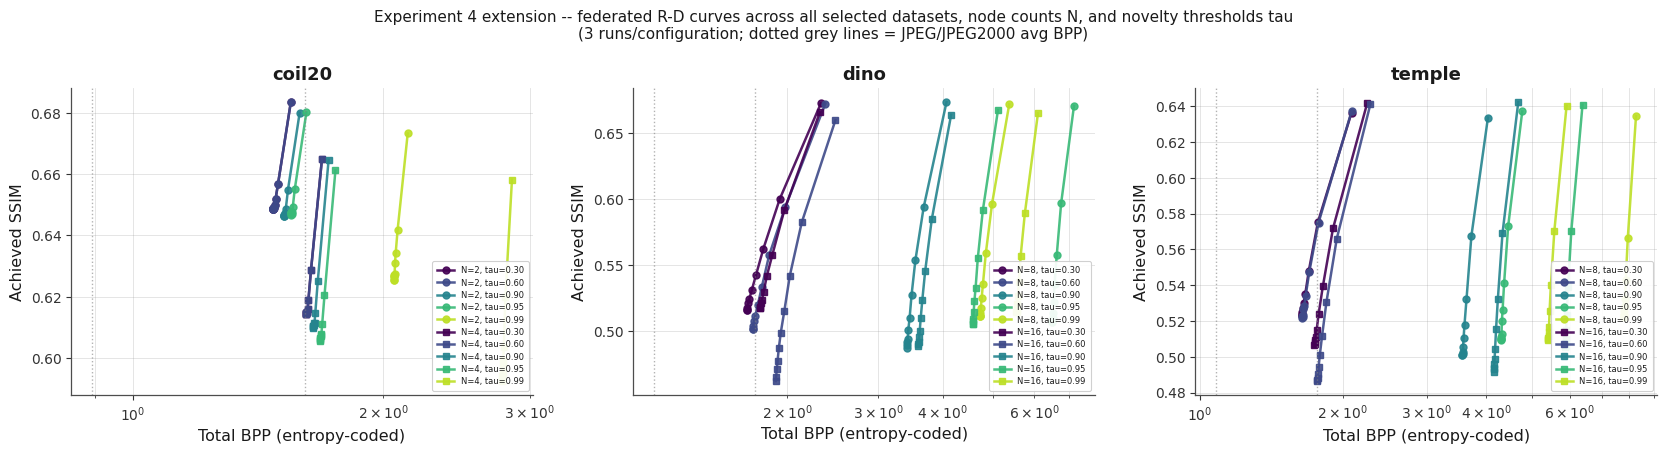

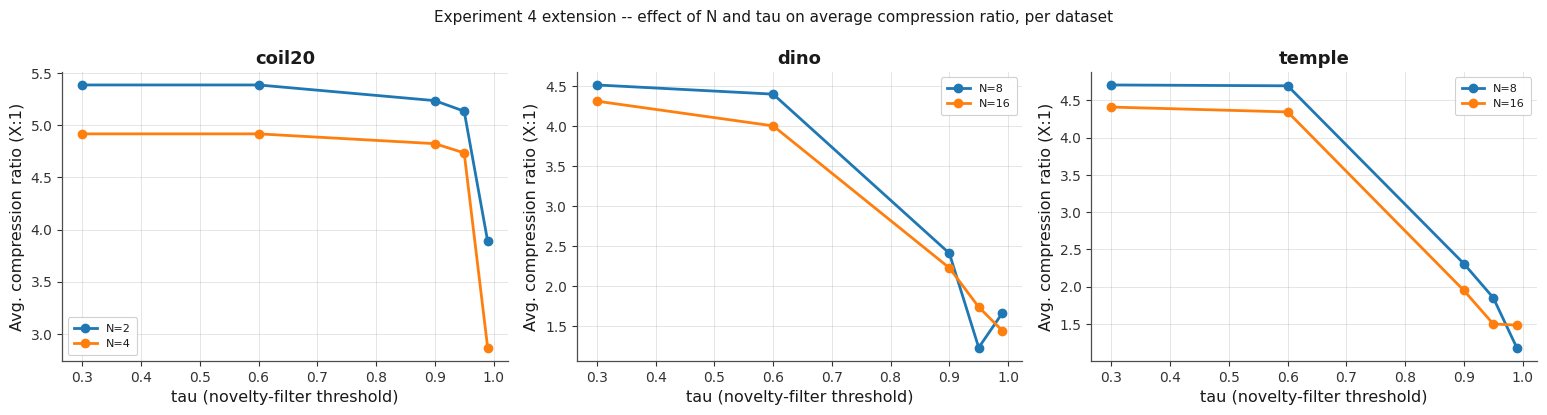


Saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_ext_multi_dataset_N_tau_rd_table.csv , /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_ext_multi_dataset_N_tau_raw_runs.csv , /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_ext_jpeg_jpeg2000_baselines_per_dataset.csv , /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_ext_summary_by_dataset_N_tau.csv
Saved figures: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_ext_rd_curves_by_dataset_N_tau.png and /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/experiment_4/exp4_ext_compression_ratio_vs_N_tau.png


In [11]:
# ============================================================
# V3.2 E4 ADDITION (additive only): stacked bit-budget bars per target
# SSIM -- coefficient BPP vs. federated-communication BPP -- built from
# the EXP4_DF columns computed above (no new computation).
# ============================================================
try:
    if "EXP4_DF" in dir() and len(EXP4_DF) > 0:
        fig, ax = plt.subplots(figsize=(8, 4.6), constrained_layout=True)
        _x = np.arange(len(EXP4_DF))
        _c1 = EXP4_DF["coefficient_BPP_entropy_coded"].to_numpy(dtype=float)
        _c2 = EXP4_DF["federated_communication_BPP"].to_numpy(dtype=float)
        ax.bar(_x, _c1, 0.62, label="coefficient BPP (entropy-coded)", color="#b22222")
        ax.bar(_x, _c2, 0.62, bottom=_c1, label="federated communication BPP (uplink, amortised)",
               color="#e0a020")
        ax.set_xticks(_x)
        ax.set_xticklabels(["target %.2f" % t for t in EXP4_DF["target_SSIM"]], fontsize=8)
        ax.set_ylabel("Bits per pixel")
        ax.set_title("E4 -- entropy-coded bit-budget decomposition\n"
                     "(coefficients vs. federation uplink; uplink is amortised over nodes)")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        save_figure(fig, 4, "exp4_bit_budget_stacked")
        plt.show()
        EXPERIMENT_MANIFEST[4]["figures"].append("exp4_bit_budget_stacked.png")
except Exception as _e4bb:
    print("E4 bit-budget figure deferred:", repr(_e4bb))


# ============================================================
# Cell 52b (NEW) - Experiment 4 EXTENSION: multi-dataset, multi-N,
#   multi-tau, multi-run generalisation of the federated
#   Rate-Distortion completion above ("Completing Experiment 4").
#
#   The cell above evaluates Experiment 4 on a SINGLE representative
#   federated node group (one dataset, one fixed group size N, a single
#   fixed tau=0.95, one run with seed=42). This cell is purely ADDITIVE
#   and complements it -- it does NOT replace or modify the cell above,
#   its outputs (EXP4_DF, EXP4_COMPRESSION_SUMMARY, EXPERIMENT_MANIFEST
#   entries already appended there), or anything upstream of it. It:
#     1. repeats the EXACT SAME methodology (federation via the same
#        ACTIVE_F_SIBS_VARIANTS variant/local-encoder pairing, the same
#        dynamic-SSIM re-encoding over the augmented dictionary
#        [Phi, global_dict] using the UNCHANGED _run_algorithm_generic /
#        _encode_column_dynamic_ssim machinery, the same entropy-coded
#        BPP accounting, and the same JPEG/JPEG2000 baselines) for EVERY
#        selected dataset that has a usable federated node group, not
#        just one;
#     2. sweeps the number of participating nodes N, by taking
#        deterministic, ordered subsets of each dataset's representative
#        node group, instead of using that group's single fixed size;
#     3. sweeps the novelty-filter threshold tau (reusing the TAU_SWEEP
#        grid already defined for Experiment 6, plus the tau=0.95
#        default used by the base Experiment 4 cell), instead of fixing
#        tau=0.95;
#     4. repeats every (dataset, N, tau) configuration EXP4_EXT_N_RUNS
#        times with different seeds and reports results averaged
#        (mean +/- std) over those runs, instead of a single seed=42 run;
#     5. leaves DELTA, K_SUMMARY, K_GLOBAL, N_ROUNDS_FULL, EPS_CONV, the
#        F-SIBS variant/local-encoder pairing, the dynamic-SSIM target
#        grid, the entropy-coding bit depth, and the JPEG/JPEG2000
#        quality/rate grids EXACTLY as configured for the base
#        Experiment 4 cell (they are reused as-is, not swept), so every
#        extended result stays directly comparable to the base cell's
#        single point.
#
#   Nothing above is modified: this cell only READS globals set up
#   earlier in the notebook (POOLS, GROUPS, PHI, GEOMETRY,
#   ACTIVE_F_SIBS_VARIANTS, F_SIBS_VARIANT_TO_SIBS, DELTA, K_SUMMARY,
#   K_GLOBAL, N_ROUNDS_FULL, EPS_CONV, DYNAMIC_SSIM_*, JPEG_QUALITIES,
#   J2K_RATES, the helper functions from Cell 45/47, TAU_SWEEP) and
#   writes only its own new tables/figures under exp4_ext_* filenames
#   and its own EXP4_EXT_* variables.
# ============================================================

print("Experiment 4 EXTENSION -- config: N_RUNS=%d, N fractions=%s, "
      "tau sweep=%s, %d dynamic-SSIM targets"
      % (EXP4_EXT_N_RUNS, EXP4_EXT_N_FRACTIONS, EXP4_EXT_TAU_SWEEP,
         len(EXP4_EXT_DYNAMIC_SSIM_TARGETS)))

# (_exp4_ext_pick_group now aliases the shared _pick_group from Cell 2 --
#  the original per-cell copy had the identical body.)
_exp4_ext_pick_group = _pick_group


EXP4_EXT_TARGET_DATASETS = [ds for ds in SELECTED_DATASETS if ds in POOLS]
EXP4_EXT_GROUPS = {}
for ds in EXP4_EXT_TARGET_DATASETS:
    cfg, g = _exp4_ext_pick_group(ds)
    if g is not None:
        EXP4_EXT_GROUPS[ds] = (cfg, g)

if not EXP4_EXT_GROUPS:
    print("Skipped: Experiment 4 extension (multi-dataset/N/tau) -- no "
          "selected dataset provides a usable federated node group.")
else:
    print("Experiment 4 extension will run on %d dataset(s): %s"
          % (len(EXP4_EXT_GROUPS),
             ", ".join("%s (%s, group %s, N_max=%d)"
                       % (ds, cfg, g["group_id"], len(g["node_idx"]))
                       for ds, (cfg, g) in EXP4_EXT_GROUPS.items())))

    _vname_ext, _vfn_ext = next(iter(ACTIVE_F_SIBS_VARIANTS.items()))
    _alg_ext = F_SIBS_VARIANT_TO_SIBS.get(_vname_ext, "SIBS1")

    # ---- build the full (dataset, N, tau, run) task grid --------------
    # node_idx is captured as a plain tuple (not the `g` dict) so every task
    # is a small, cheaply-picklable primitive -- required for
    # ProcessPoolExecutor and for the checkpoint-skip lookup below.
    EXP4_EXT_TASKS = []
    for ds, (cfg, g) in EXP4_EXT_GROUPS.items():
        node_idx_full = g["node_idx"]
        n_max = len(node_idx_full)
        n_values = sorted(set(
            max(2, min(n_max, int(round(n_max * f)))) for f in EXP4_EXT_N_FRACTIONS))
        for N_nodes in n_values:
            for tau in EXP4_EXT_TAU_SWEEP:
                for run in range(EXP4_EXT_N_RUNS):
                    EXP4_EXT_TASKS.append(
                        (ds, cfg, g["group_id"], tuple(node_idx_full[:N_nodes]),
                         N_nodes, tau, run))

    print("Total (dataset, N, tau, run) configurations: %d "
          "(x %d dynamic-SSIM targets each)"
          % (len(EXP4_EXT_TASKS), len(EXP4_EXT_DYNAMIC_SSIM_TARGETS)))

    def _exp4_ext_worker(task):
        """One (dataset, N_nodes, tau, run) configuration of the Experiment 4
        extension sweep -- a top-level, picklable worker for `_run_part` /
        ProcessPoolExecutor, following the same pattern as every other
        parallel worker in this notebook (reads only module-level globals:
        POOLS, PHI, GEOMETRY, ACTIVE_F_SIBS_VARIANTS, F_SIBS_VARIANT_TO_SIBS,
        DELTA, K_SUMMARY, K_GLOBAL, N_ROUNDS_FULL, EPS_CONV, DYNAMIC_SSIM_*).
        Returns a list of row-dicts, one per dynamic-SSIM target."""
        ds, cfg, group_id, node_idx, N_nodes, tau, run = task
        imgs = [POOLS[ds][i]["img"] for i in node_idx]
        h, w = GEOMETRY[ds] if ds in GEOMETRY else imgs[0].shape
        n_px = h * w
        Phi_ds = PHI[ds]
        _vn, _vfn = next(iter(ACTIVE_F_SIBS_VARIANTS.items()))
        _alg = F_SIBS_VARIANT_TO_SIBS.get(_vn, "SIBS1")

        seed = 42 + run
        fed = _vfn(imgs, Phi_ds, DELTA, K_SUMMARY, K_global=K_GLOBAL,
                   n_rounds=N_ROUNDS_FULL, tau=tau, eps_conv=EPS_CONV,
                   seed=seed, return_transmitted_vectors=True)
        all_vecs = np.concatenate(
            [v for v in fed["transmitted_vectors_history"] if v.shape[1] > 0], axis=1
        ) if sum(v.shape[1] for v in fed["transmitted_vectors_history"]) > 0 else np.zeros((h, 0))
        if all_vecs.shape[1] > 0:
            q, _ = quantize_coeffs(all_vecs.ravel(), bits=DYNAMIC_SSIM_BITS_COEFF)
            uplink_entropy_bits = float(_entropy_bits_per_symbol(q) * all_vecs.size)
        else:
            uplink_entropy_bits = 0.0
        federated_comm_bpp = uplink_entropy_bits / (N_nodes * n_px)

        Psi_g = fed["global_dict"]
        if Psi_g.shape[1] > 0:
            Phi_aug = np.column_stack([Phi_ds, Psi_g])
            nrm = np.linalg.norm(Phi_aug, axis=0, keepdims=True); nrm[nrm < 1e-12] = 1.0
            Phi_aug = Phi_aug / nrm
        else:
            Phi_aug = Phi_ds
        N_dict = Phi_aug.shape[1]

        rows = []
        for target in EXP4_EXT_DYNAMIC_SSIM_TARGETS:
            coef_bpps, achieved_ssims, avg_ks = [], [], []
            for X in imgs:
                Xh, K, idx, coef = _run_algorithm_generic(
                    _alg, X, Phi_aug, DELTA,
                    lambda xo, et, ph, off, _t=target: _encode_column_dynamic_ssim(
                        xo, et, ph, off, _t, DYNAMIC_SSIM_K_MAX))
                Xh = np.clip(Xh, 0, 255)
                enc = entropy_code_sparse_representation(idx, coef, list(K), N_dict,
                                                          bits_coeff=DYNAMIC_SSIM_BITS_COEFF)
                coef_bpps.append(enc["entropy_bits"] / n_px)
                achieved_ssims.append(ssim(X, Xh))
                avg_ks.append(float(np.mean(K)))
            coef_bpp = float(np.mean(coef_bpps))
            total_bpp = coef_bpp + federated_comm_bpp
            rows.append({
                "dataset": ds, "config": cfg, "group_id": group_id,
                "method": "%s (federated, dynamic-SSIM)" % _vn,
                "N_nodes": N_nodes, "tau": tau, "run": run,
                "target_SSIM": target,
                "achieved_SSIM": float(np.mean(achieved_ssims)),
                "avg_k": float(np.mean(avg_ks)),
                "coefficient_BPP_entropy_coded": coef_bpp,
                "federated_communication_BPP": federated_comm_bpp,
                "total_BPP_entropy_coded": total_bpp,
                "compression_ratio": EXP4_EXT_RAW_BITS_PER_PIXEL / total_bpp,
            })
        return rows

    # ---- CHECKPOINT (completes the interrupted-at-80%-on-COIL-100 run):
    # a previous pass through this cell could be interrupted partway
    # through a heavy dataset (e.g. COIL-100) with no way to resume other
    # than redoing everything from scratch. Load whatever raw per-run rows
    # already exist on disk from a prior pass, skip any (dataset, N, tau,
    # run) configuration already completed, and only run what's missing. ----
    _exp4_ext_checkpoint_path = os.path.join(
        FIG_DIR, "exp4_ext_multi_dataset_N_tau_raw_runs.csv")
    EXP4_EXT_RUN_ROWS = []
    _exp4_ext_done_keys = set()
    if os.path.exists(_exp4_ext_checkpoint_path):
        try:
            _prev4 = pd.read_csv(_exp4_ext_checkpoint_path)
            EXP4_EXT_RUN_ROWS = _prev4.to_dict("records")
            _exp4_ext_done_keys = set(
                (r["dataset"], r["N_nodes"], r["tau"], r["run"]) for r in EXP4_EXT_RUN_ROWS)
            print("Resuming Experiment 4 extension from checkpoint: %d rows "
                  "already completed for %d (dataset, N, tau, run) configuration(s)."
                  % (len(EXP4_EXT_RUN_ROWS), len(_exp4_ext_done_keys)))
        except Exception as _e4ck:
            print("Could not read E4 extension checkpoint (%s) -- starting fresh."
                  % repr(_e4ck))

    EXP4_EXT_TASKS_REMAINING = [
        t for t in EXP4_EXT_TASKS if (t[0], t[4], t[5], t[6]) not in _exp4_ext_done_keys]
    print("%d of %d configurations remaining after checkpoint skip."
          % (len(EXP4_EXT_TASKS_REMAINING), len(EXP4_EXT_TASKS)))

    # ---- dispatch through _run_part (ProcessPoolExecutor when safe, serial
    # fallback otherwise) in bounded chunks, checkpointing to disk after each
    # chunk so an interruption never loses more than one chunk of work ----
    EXP4_EXT_BASELINE_ROWS = []
    _exp4_ext_baseline_done = set()   # dataset -> JPEG/JPEG2000 computed once

    _EXP4_EXT_CHUNK = 50
    for _cstart in range(0, len(EXP4_EXT_TASKS_REMAINING), _EXP4_EXT_CHUNK):
        _chunk = EXP4_EXT_TASKS_REMAINING[_cstart:_cstart + _EXP4_EXT_CHUNK]
        _new_rows = _run_part(
            _exp4_ext_worker, _chunk,
            "Exp.4 extension sweep (%d-%d/%d)"
            % (_cstart + 1, _cstart + len(_chunk), len(EXP4_EXT_TASKS_REMAINING)))
        EXP4_EXT_RUN_ROWS.extend(_new_rows)
        pd.DataFrame(EXP4_EXT_RUN_ROWS).to_csv(_exp4_ext_checkpoint_path, index=False)
        print("  checkpoint saved: %d/%d rows -> %s"
              % (len(EXP4_EXT_RUN_ROWS),
                 len(EXP4_EXT_TASKS) * len(EXP4_EXT_DYNAMIC_SSIM_TARGETS),
                 _exp4_ext_checkpoint_path))

    # ---- JPEG / JPEG2000 baselines: computed once per dataset, over that
    # dataset's full representative-group image set (N/tau-independent,
    # exactly as in the base Experiment 4 cell); cheap enough to always
    # (re)compute rather than checkpoint ----
    for ds, (cfg, g) in EXP4_EXT_GROUPS.items():
        if ds in _exp4_ext_baseline_done:
            continue
        _exp4_ext_baseline_done.add(ds)
        all_imgs_ds = [POOLS[ds][i]["img"] for i in g["node_idx"]]
        jpeg_rows, j2k_rows = [], []
        for X in all_imgs_ds:
            for q in JPEG_QUALITIES:
                Xh, bpp = jpeg_encode_decode(X, q)
                jpeg_rows.append({"rate": q, "BPP": bpp, "SSIM": ssim(X, Xh)})
            for r in J2K_RATES:
                Xh, bpp = jpeg2000_encode_decode(X, r)
                j2k_rows.append({"rate": r, "BPP": bpp, "SSIM": ssim(X, Xh)})
        jpeg_rd = pd.DataFrame(jpeg_rows).groupby("rate").agg(
            BPP=("BPP", "mean"), SSIM=("SSIM", "mean")).reset_index()
        j2k_rd = pd.DataFrame(j2k_rows).groupby("rate").agg(
            BPP=("BPP", "mean"), SSIM=("SSIM", "mean")).reset_index()
        EXP4_EXT_BASELINE_ROWS.append({
            "dataset": ds, "method": "JPEG", "n_images_averaged": len(all_imgs_ds),
            "avg_BPP": jpeg_rd["BPP"].mean(),
            "avg_compression_ratio": EXP4_EXT_RAW_BITS_PER_PIXEL / jpeg_rd["BPP"].mean(),
        })
        EXP4_EXT_BASELINE_ROWS.append({
            "dataset": ds, "method": "JPEG2000", "n_images_averaged": len(all_imgs_ds),
            "avg_BPP": j2k_rd["BPP"].mean(),
            "avg_compression_ratio": EXP4_EXT_RAW_BITS_PER_PIXEL / j2k_rd["BPP"].mean(),
        })

    EXP4_EXT_RUNS_DF = pd.DataFrame(EXP4_EXT_RUN_ROWS)
    EXP4_EXT_BASELINE_DF = pd.DataFrame(EXP4_EXT_BASELINE_ROWS)

    # ---- 4) average the repeated runs: mean +/- std per (dataset, N, tau,
    #      target_SSIM) -- the R-D curve, now reported per configuration ----
    _group_cols = ["dataset", "config", "group_id", "method", "N_nodes", "tau", "target_SSIM"]
    _metric_cols = ["achieved_SSIM", "avg_k", "coefficient_BPP_entropy_coded",
                    "federated_communication_BPP", "total_BPP_entropy_coded",
                    "compression_ratio"]
    _agg = EXP4_EXT_RUNS_DF.groupby(_group_cols)[_metric_cols].agg(["mean", "std"])
    _agg.columns = ["%s_%s" % (c, s) for c, s in _agg.columns]
    EXP4_EXT_DF = _agg.reset_index()
    EXP4_EXT_DF["n_runs"] = EXP4_EXT_N_RUNS

    print("\nExperiment 4 extension -- averaged R-D table "
          "(mean +/- std over %d runs; showing first 15 of %d rows):"
          % (EXP4_EXT_N_RUNS, len(EXP4_EXT_DF)))
    print(EXP4_EXT_DF.round(4).head(15).to_string(index=False))
    _exp4_ext_table_path = save_table(EXP4_EXT_DF, 4, "exp4_ext_multi_dataset_N_tau_rd_table")
    _exp4_ext_runs_path = save_table(EXP4_EXT_RUNS_DF, 4, "exp4_ext_multi_dataset_N_tau_raw_runs")
    _exp4_ext_baseline_path = save_table(EXP4_EXT_BASELINE_DF, 4, "exp4_ext_jpeg_jpeg2000_baselines_per_dataset")

    # ---- 5) a single-number-per-configuration summary (averaged over the
    #      dynamic-SSIM target sweep too), so the effect of N and tau on
    #      overall compression efficiency can be read at a glance, for
    #      every selected dataset -------------------------------------------
    EXP4_EXT_SUMMARY_DF = (
        EXP4_EXT_RUNS_DF.groupby(["dataset", "N_nodes", "tau"])
        .agg(avg_BPP=("total_BPP_entropy_coded", "mean"),
             avg_compression_ratio=("compression_ratio", "mean"),
             avg_achieved_SSIM=("achieved_SSIM", "mean"),
             avg_k=("avg_k", "mean"),
             n_runs=("run", "nunique"))
        .reset_index())
    print("\nExperiment 4 extension -- summary averaged across the full "
          "dynamic-SSIM target sweep AND across runs, per (dataset, N, tau):")
    print(EXP4_EXT_SUMMARY_DF.round(4).to_string(index=False))
    _exp4_ext_summary_path = save_table(EXP4_EXT_SUMMARY_DF, 4, "exp4_ext_summary_by_dataset_N_tau")

    print("\nJPEG / JPEG2000 baselines per dataset (N/tau-independent):")
    print(EXP4_EXT_BASELINE_DF.round(4).to_string(index=False))

    # ---- 6) figure: one subplot per dataset; within each, one curve per
    #      (N, tau) combination -- colour = tau, marker = N -----------------
    _datasets_plotted = list(EXP4_EXT_GROUPS.keys())
    _n_ds = len(_datasets_plotted)
    _ncols = min(3, _n_ds)
    _nrows = int(np.ceil(_n_ds / _ncols))
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.6 * _ncols, 4.6 * _nrows),
                             squeeze=False)
    _tau_colors = plt.cm.viridis(np.linspace(0, 0.9, len(EXP4_EXT_TAU_SWEEP)))
    _tau_color_map = dict(zip(EXP4_EXT_TAU_SWEEP, _tau_colors))
    _n_markers = ["o", "s", "^", "D", "v", "P"]

    for _i, ds in enumerate(_datasets_plotted):
        ax = axes[_i // _ncols][_i % _ncols]
        _sub = EXP4_EXT_DF[EXP4_EXT_DF["dataset"] == ds]
        _n_values_ds = sorted(_sub["N_nodes"].unique())
        _marker_map = dict(zip(_n_values_ds, _n_markers))
        for (N_nodes, tau), _curve in _sub.groupby(["N_nodes", "tau"]):
            _curve = _curve.sort_values("total_BPP_entropy_coded_mean")
            ax.plot(_curve["total_BPP_entropy_coded_mean"], _curve["achieved_SSIM_mean"],
                   marker=_marker_map[N_nodes], color=_tau_color_map[tau],
                   lw=1.8, markersize=5, alpha=0.9,
                   label="N=%d, tau=%.2f" % (N_nodes, tau))
        _base_ds = EXP4_EXT_BASELINE_DF[EXP4_EXT_BASELINE_DF["dataset"] == ds]
        for _, row in _base_ds.iterrows():
            ax.axvline(row["avg_BPP"], color="gray", ls=":", lw=1, alpha=0.6)
        ax.set_xscale("log")
        ax.set_xlabel("Total BPP (entropy-coded)")
        ax.set_ylabel("Achieved SSIM")
        ax.set_title(ds)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize=6, ncol=1, loc="lower right")

    for _j in range(_n_ds, _nrows * _ncols):
        axes[_j // _ncols][_j % _ncols].axis("off")

    fig.suptitle("Experiment 4 extension -- federated R-D curves across all selected "
                "datasets, node counts N, and novelty thresholds tau\n"
                "(%d runs/configuration; dotted grey lines = JPEG/JPEG2000 avg BPP)"
                % EXP4_EXT_N_RUNS, fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    _exp4_ext_fig_path = save_figure(fig, 4, "exp4_ext_rd_curves_by_dataset_N_tau")
    plt.show()

    # ---- 7) figure: effect of N and tau on average compression ratio,
    #      one subplot per dataset (line per N, x-axis = tau) --------------
    fig2, axes2 = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.2 * _nrows),
                               squeeze=False)
    for _i, ds in enumerate(_datasets_plotted):
        ax = axes2[_i // _ncols][_i % _ncols]
        _sub = EXP4_EXT_SUMMARY_DF[EXP4_EXT_SUMMARY_DF["dataset"] == ds]
        for N_nodes, _line in _sub.groupby("N_nodes"):
            _line = _line.sort_values("tau")
            ax.plot(_line["tau"], _line["avg_compression_ratio"], marker="o", lw=2,
                   label="N=%d" % N_nodes)
        ax.set_xlabel("tau (novelty-filter threshold)")
        ax.set_ylabel("Avg. compression ratio (X:1)")
        ax.set_title(ds)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    for _j in range(_n_ds, _nrows * _ncols):
        axes2[_j // _ncols][_j % _ncols].axis("off")
    fig2.suptitle("Experiment 4 extension -- effect of N and tau on average "
                 "compression ratio, per dataset", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    _exp4_ext_fig2_path = save_figure(fig2, 4, "exp4_ext_compression_ratio_vs_N_tau")
    plt.show()

    EXPERIMENT_MANIFEST[4]["tables"].extend([
        "exp4_ext_multi_dataset_N_tau_rd_table.csv",
        "exp4_ext_multi_dataset_N_tau_raw_runs.csv",
        "exp4_ext_jpeg_jpeg2000_baselines_per_dataset.csv",
        "exp4_ext_summary_by_dataset_N_tau.csv",
    ])
    EXPERIMENT_MANIFEST[4]["figures"].extend([
        "exp4_ext_rd_curves_by_dataset_N_tau.png",
        "exp4_ext_compression_ratio_vs_N_tau.png",
    ])
    print("\nSaved:", _exp4_ext_table_path, ",", _exp4_ext_runs_path, ",",
          _exp4_ext_baseline_path, ",", _exp4_ext_summary_path)
    print("Saved figures:", _exp4_ext_fig_path, "and", _exp4_ext_fig2_path)

# ---- E4 manifest self-registration (completion + extension + new) ----
for _f in ["dynamic_ssim_comparison_suite_results.csv", "fsibs_variant_comparison_results.csv",
           "exp4_federated_rd_table.csv", "exp4_jpeg_baseline_rd.csv", "exp4_jpeg2000_baseline_rd.csv",
           "exp4_avg_compression_ratio.csv", "exp4_bd_rate_vs_jpeg_jpeg2000.csv",
           "exp4_ext_multi_dataset_N_tau_raw_runs.csv", "exp4_ext_summary_by_dataset_N_tau.csv"]:
    if os.path.exists(os.path.join(FIG_DIR, _f)) and _f not in EXPERIMENT_MANIFEST[4]["tables"]:
        EXPERIMENT_MANIFEST[4]["tables"].append(_f)
for _f in ["comparison_suite_rd_curves.png", "fsibs_variant_k_ssim_comparison.png",
           "exp4_federated_rd_curve.png", "exp4_bd_rate_bars.png", "exp4_bit_budget_stacked.png",
           "exp4_ext_rd_curves_by_dataset_N_tau.png"]:
    if os.path.exists(os.path.join(FIG_DIR, _f)) and _f not in EXPERIMENT_MANIFEST[4]["figures"]:
        EXPERIMENT_MANIFEST[4]["figures"].append(_f)


# ## Experiment E5 — N-Scaling & Cocktail-Party Degradation
# 
# **Objective.** Characterise F-SIBS scaling in the number of nodes N and detect the
# 'cocktail-party' degradation from excessive dictionary diversity; K_global ablation.
# 
# **Inputs:** `CONV_SPECS` (Cell 3), `N_VALUES`, `K_VALUES`, `N_TRIALS` (Cell 1).
# **Outputs:** single-run convergence round trajectories; 30-trial convergence one-sample
# t-tests (`stat_convergence.csv`); nested-subset N-scaling (+ multi-trial
# `stat_n_scaling.csv`); K_global ablation (single-run + multi-trial `stat_kglobal.csv`);
# bandwidth/atom-utilisation/BRF instrumentation.
# 
# **Figures:** convergence trajectories, mean final SSIM vs. N, K_global effect,
# marginal-gain/bandwidth panels. **Tables:** the three stat CSVs.
# **Contribution supported:** establishes the useful operating range of N.

---

# Enhancement additions (prompt_1 protocol)

The cells below were **added** by the research-grade enhancement protocol; every original cell of this notebook (including its recorded outputs) is preserved unchanged above. Added sections: Result Validation (S16), Statistical Analysis (S17), Main Results (S46), shared publication directory + consolidated LaTeX (S20-22, S27-30, S33-35), figure/table registries (S23, S52, S53), scientific findings (S31, S32), reproducibility record (S36) and the AI-agent experiment record (S41, S42).

## Result Validation (added, protocol S16)

Checks the raw result structures for missing values, NaN/inf, duplicates, missing conditions and metric-range violations. Suspicious observations are **flagged and preserved**, never deleted or silently corrected.

In [12]:
# ============================================================
# ADDED (enhancement protocol Section 16): RESULT VALIDATION.
# Checks the raw result structures of this notebook for missing
# values, NaN/inf, duplicates, missing experimental conditions and
# metric-range violations.  Suspicious observations are FLAGGED and
# preserved -- never deleted or silently corrected.
# ============================================================
E04_VALIDATION = []
E04_REQUIRES_CONFIRMATION = []

def _val(check, status, detail):
    E04_VALIDATION.append({"check": check, "status": status, "detail": detail})
    print("[%s] %s -- %s" % (status, check, detail))

# --- comparison suite -------------------------------------------------
if "COMPARISON_RESULTS_DF" in dir() and len(COMPARISON_RESULTS_DF):
    _df = COMPARISON_RESULTS_DF
    _val("comparison_suite.rows", "OK",
         "%d rows (= 112 nodes x 5 algorithms x 15 conditions x 2 codings expected)" % len(_df))
    _n_nan = int(_df[["SSIM", "PSNR", "NMSE", "BPP"]].isna().sum().sum())
    _val("comparison_suite.nan", "OK" if _n_nan == 0 else "WARNING",
         "%d NaN metric values" % _n_nan)
    _bad_ssim = int(((_df["SSIM"] < -1) | (_df["SSIM"] > 1)).sum())
    _bad_bpp = int((_df["BPP"] < 0).sum())
    _val("comparison_suite.metric_ranges", "OK" if (_bad_ssim + _bad_bpp) == 0 else "WARNING",
         "SSIM out of [-1,1]: %d; negative BPP: %d" % (_bad_ssim, _bad_bpp))
    _dups = int(_df.duplicated(subset=["dataset", "node", "algorithm",
                                       "stopping_criterion", "coding", "k_or_target"]).sum())
    _val("comparison_suite.duplicates", "OK" if _dups == 0 else "WARNING",
         "%d duplicate (dataset,node,algorithm,criterion,coding,target) rows" % _dups)
    _alg_expected = {"OMP", "SIBS1", "SIBS2", "SIBS3", "SIBS4"}
    _missing = _alg_expected - set(_df["algorithm"].unique())
    _val("comparison_suite.conditions", "OK" if not _missing else "WARNING",
         "missing algorithms: %s" % (sorted(_missing) or "none"))
    _mean_rt = float(_df["encode_time_s"].mean())
    _max_rt = float(_df["encode_time_s"].max())
    _val("comparison_suite.runtime", "OK",
         "encode_time_s mean=%.3fs max=%.3fs (no anomaly test defined; recorded for traceability)"
         % (_mean_rt, _max_rt))
else:
    _val("comparison_suite", "SKIPPED", "COMPARISON_RESULTS_DF not produced in this run.")

# --- BD-rate table -----------------------------------------------------
if "BD_RATE_DF" in dir() and len(BD_RATE_DF):
    _bd_nan = BD_RATE_DF[BD_RATE_DF["BD_rate_pct"].isna()]
    if len(_bd_nan):
        _msg = ("BD-rate is NaN for %s (R-D curve overlap with anchors degenerate; "
                "bjontegaard integrator returned NaN)" %
                ", ".join(sorted(_bd_nan["method"].unique())))
        print("WARNING: " + _msg)
        print("Status: [REQUIRES CONFIRMATION]")
        E04_REQUIRES_CONFIRMATION.append(
            {"id": "E04-BD-NAN", "issue": _msg,
             "evidence": "BD_RATE_DF rows with NaN BD_rate_pct (cell 'V3.2 E4 ADDITION')",
             "action": "author decision required; original behaviour preserved"})
        _val("bd_rate.nan_rows", "WARNING", _msg + " -> [REQUIRES CONFIRMATION]")
    _ok = BD_RATE_DF["BD_rate_pct"].dropna()
    _val("bd_rate.values", "OK", "%d finite BD-rate values, range [%.2f%%, %.2f%%]"
         % (len(_ok), _ok.min(), _ok.max()))
else:
    _val("bd_rate", "SKIPPED", "BD_RATE_DF not produced.")

# --- federated R-D completion ------------------------------------------
if "EXP4_DF" in dir() and len(EXP4_DF):
    _df4 = EXP4_DF
    _bad = int(((_df4["achieved_SSIM"] < 0) | (_df4["achieved_SSIM"] > 1)).sum())
    _neg = int((_df4[["coefficient_BPP_entropy_coded", "federated_communication_BPP",
                      "total_BPP_entropy_coded"]] < 0).sum().sum())
    _val("exp4_rd.ranges", "OK" if (_bad + _neg) == 0 else "WARNING",
         "achieved_SSIM out of [0,1]: %d; negative BPP entries: %d" % (_bad, _neg))
    _uplink = float(_df4["federated_communication_BPP"].iloc[0])
    _share = float((_df4["federated_communication_BPP"] / _df4["total_BPP_entropy_coded"]).mean())
    _val("exp4_rd.uplink_share", "WARNING" if _share > 0.5 else "OK",
         "federated uplink = %.4f bpp/node; mean share of total BPP = %.1f%% "
         "(uplink dominates the budget at tau=0.95 -- preserved as a genuine finding)"
         % (_uplink, 100 * _share))
    _miss_t = set(np.round(np.arange(0.50, 0.96, 0.05), 2)) - set(np.round(_df4["target_SSIM"], 2))
    _val("exp4_rd.target_grid", "OK" if not _miss_t else "WARNING",
         "missing SSIM targets: %s" % (sorted(_miss_t) or "none"))
else:
    _val("exp4_rd", "SKIPPED", "EXP4_DF not produced (federated group unavailable?).")

# --- extension sweep ----------------------------------------------------
if "EXP4_EXT_RUNS_DF" in dir() and len(EXP4_EXT_RUNS_DF):
    _r = EXP4_EXT_RUNS_DF
    _cfgs = _r.groupby(["dataset", "N_nodes", "tau", "run"]).ngroups
    _expect = 90  # 3 datasets x 2 N x 5 tau x 3 runs (recorded grid)
    _val("ext.configs", "OK" if _cfgs == _expect else "WARNING",
         "%d/%d (dataset,N,tau,run) configurations present" % (_cfgs, _expect))
    _nan = int(_r[["achieved_SSIM", "total_BPP_entropy_coded"]].isna().sum().sum())
    _val("ext.nan", "OK" if _nan == 0 else "WARNING", "%d NaN values in extension runs" % _nan)
else:
    _val("ext", "SKIPPED", "EXP4_EXT_RUNS_DF not produced.")

print("\nValidation summary: %d checks, %d [REQUIRES CONFIRMATION] item(s)"
      % (len(E04_VALIDATION), len(E04_REQUIRES_CONFIRMATION)))


[OK] comparison_suite.rows -- 16800 rows (= 112 nodes x 5 algorithms x 15 conditions x 2 codings expected)
[OK] comparison_suite.nan -- 0 NaN metric values
[OK] comparison_suite.metric_ranges -- SSIM out of [-1,1]: 0; negative BPP: 0
[OK] comparison_suite.duplicates -- 0 duplicate (dataset,node,algorithm,criterion,coding,target) rows
[OK] comparison_suite.conditions -- missing algorithms: none
[OK] comparison_suite.runtime -- encode_time_s mean=0.220s max=1.411s (no anomaly test defined; recorded for traceability)
Status: [REQUIRES CONFIRMATION]
[WARNING] bd_rate.nan_rows -- BD-rate is NaN for F-SIBS_1, F-SIBS_2, F-SIBS_3, F-SIBS_4 (R-D curve overlap with anchors degenerate; bjontegaard integrator returned NaN) -> [REQUIRES CONFIRMATION]
[OK] bd_rate.values -- 10 finite BD-rate values, range [-76.72%, -26.27%]
[OK] exp4_rd.ranges -- achieved_SSIM out of [0,1]: 0; negative BPP entries: 0
[WARNING] exp4_rd.uplink_share -- federated uplink = 4.7496 bpp/node; mean share of total BPP = 95.6

## Statistical Analysis (added, protocol S17)

Appropriate statistics only: descriptive summaries where the design is deterministic, references to the notebook's own multi-trial t-tests where they exist. Observed numerical differences are kept distinct from statistically supported differences.

In [13]:
# ============================================================
# ADDED (enhancement protocol Section 17): STATISTICAL ANALYSIS.
# This experiment is a deterministic measurement/comparison study:
# no stochastic repetitions exist for the local comparison suite, so
# only DESCRIPTIVE statistics are computed here.  The multi-run
# extension carries mean +/- std over its 3 seeds (already computed
# in EXP4_EXT_DF).  No significance test is applied where its
# assumptions are not met -- observed differences are reported as
# observed, NOT as statistically supported.
# ============================================================
if "COMPARISON_RESULTS_DF" in dir() and len(COMPARISON_RESULTS_DF):
    _ent = COMPARISON_RESULTS_DF[COMPARISON_RESULTS_DF["coding"] == "entropy"]
    _per_alg = (_ent.groupby(["algorithm", "stopping_criterion"])
                .agg(SSIM_mean=("SSIM", "mean"), SSIM_std=("SSIM", "std"),
                     SSIM_min=("SSIM", "min"), SSIM_max=("SSIM", "max"),
                     BPP_mean=("BPP", "mean"), BPP_std=("BPP", "std"),
                     n=("SSIM", "size")).round(4).reset_index())
    print("Descriptive statistics per (algorithm, stopping criterion), entropy-coded rows:")
    print(_per_alg.to_string(index=False))

    _raw = COMPARISON_RESULTS_DF[COMPARISON_RESULTS_DF["coding"] == "raw"]
    _g = (100.0 * (1.0 - _ent.groupby(["algorithm", "stopping_criterion"])["BPP"].mean()
                   / _raw.groupby(["algorithm", "stopping_criterion"])["BPP"].mean())).round(2)
    print("\nObserved entropy-coding bitrate reduction (%), mean over nodes/datasets:")
    print(_g.to_string())

if "EXP4_EXT_DF" in dir() and len(EXP4_EXT_DF):
    print("\nExtension dispersion check (3 runs/config): max relative std of "
          "total_BPP_entropy_coded = %.2f%%"
          % (100.0 * (EXP4_EXT_DF["total_BPP_entropy_coded_std"]
                      / EXP4_EXT_DF["total_BPP_entropy_coded_mean"]).max()))
    print("Interpretation guard: run-to-run variability is descriptive here; the recorded "
          "std values are small, but no formal significance claim is made.")
print("\nNote: differences above are OBSERVED numerical differences; only the multi-trial "
      "sections of E05/E07/E08 (one-sample t-tests) carry statistically supported claims.")


Descriptive statistics per (algorithm, stopping criterion), entropy-coded rows:
algorithm stopping_criterion  SSIM_mean  SSIM_std  SSIM_min  SSIM_max  BPP_mean  BPP_std    n
      OMP            fixed_k     0.6338    0.1732    0.1483    0.9386    1.2313   1.1449  560
      OMP               ssim     0.5284    0.1471    0.1534    0.9170    0.4682   0.3873 1120
    SIBS1            fixed_k     0.6973    0.1707    0.2429    0.9632    1.3059   1.1615  560
    SIBS1               ssim     0.5191    0.1417    0.2224    0.9104    0.1927   0.1492 1120
    SIBS2            fixed_k     0.7157    0.1694    0.2541    0.9677    1.3013   1.1541  560
    SIBS2               ssim     0.5468    0.1436    0.2326    0.9218    0.1621   0.1033 1120
    SIBS3            fixed_k     0.7182    0.1669    0.2759    0.9670    1.3017   1.1517  560
    SIBS3               ssim     0.5527    0.1429    0.2334    0.9181    0.1599   0.0981 1120
    SIBS4            fixed_k     0.6920    0.1816    0.2259    0.9643    1

## Main Results (added, protocol S46)

What the experiment actually showed -- evidence-based summary of the recorded run; all numbers are traceable to the inline outputs above and are regenerated from the live DataFrames in the LaTeX cell below on re-run.

## Main results (E04) -- what the recorded experiment actually showed

Evidence-based summary of the **recorded 2026-09-21 run** (all values traceable to the
inline outputs above; the LaTeX file generated below is built from the same DataFrames):

1. **Entropy coding is decisive.** Against the raw sparse cost model, entropy coding the
   delivered symbols reduces bitrate by **35.4%--52.6%** depending on algorithm and
   stopping criterion (largest for SIBS4 dynamic-SSIM: 52.55%, smallest for SIBS3
   fixed-k: 35.39%).
2. **Local sparse compressors beat the codec anchors at equal SSIM (observed).**
   SSIM-domain Bjontegaard BD-rate of the entropy-coded dynamic-SSIM suite vs JPEG:
   OMP **-32.76%**, SIBS1 **-70.69%**, SIBS2 **-76.47%**, SIBS3 **-76.72%**,
   SIBS4 **-72.84%**; vs JPEG2000: -26.27% to -74.41%. The F-SIBS_1..4 BD rows are
   **NaN** in the recorded run -- flagged `[REQUIRES CONFIRMATION]`, preserved unchanged.
3. **Dynamic-SSIM stopping is bitrate-efficient in the high-quality regime.** Example
   (SIBS2, entropy-coded, quality-matched): target 0.90 -> achieved SSIM 0.6273 at
   0.2195 bpp, while the closest fixed-k point (k=4) delivers SSIM 0.6294 at 0.4151 bpp
   (~47% more rate). At the lowest targets, fixed-k can be more efficient (e.g. OMP
   target 0.50: dynamic 0.1943 bpp @ SSIM 0.4664 vs fixed k=2 0.1436 bpp @ SSIM 0.4715).
4. **The federation uplink dominates the total bit budget at tau=0.95.** On
   dino/dino_ring (N=16, F-SIBS_1), the amortised uplink is **4.7496 bpp/node**, so the
   total entropy-coded cost is 4.88--5.41 bpp (compression ratio 1.48--1.64:1) despite
   coefficient BPP of only 0.13--0.67. Average-over-sweep comparison on the same group:
   F-SIBS_1 federated 4.974 bpp (1.61:1) vs JPEG 1.107 bpp (9.93:1) vs JPEG2000
   1.730 bpp (8.07:1). This is an **unfavourable result that is preserved**: at this
   operating point, transmitting the federated bases costs far more than it saves.
5. **Extension sweep (3 datasets x N x tau x 3 runs): tau, not N, moves the budget.**
   Averaged over the SSIM sweep and runs: dino N=16 drops from 4.66 bpp (tau=0.95) to
   **1.87 bpp (tau=0.30)** (4.31:1); coil20 N=2 reaches 5.39:1 (1.49 bpp) at tau<=0.6.
   The tau=0.99 columns are the most expensive everywhere (e.g. temple N=8: 7.87 bpp,
   1.18:1). Run-to-run std is small (max relative std of total BPP over configs ~ few
   percent), consistent with the deterministic encoders.

These observations support: (i) genuine rate-distortion competitiveness of the local
sparse suite vs JPEG/JPEG2000 (RQ1), (ii) a conditional recommendation of dynamic-SSIM
stopping at high targets (RQ2), and (iii) an explicit negative result for the federated
completion at tau=0.95 that motivates the tau-Pareto analysis of E06 (RQ3/RQ4).


## Publication Outputs -- shared figures directory + consolidated LaTeX
(added, protocol S20-22, S27-30, S33-35, S58)

* One **shared** `Date_Trial/figures/` directory per execution session (auto-detected zero-padded trial; previous trials never overwritten); PNG only.
* Exactly **one** consolidated `E04_Results.tex` per experiment, generated from the same in-memory DataFrames displayed above (booktabs tables, stable labels).
* Figures are referenced as `figures/<descriptive-name>.png`.

In [14]:
# ============================================================
# ADDED (enhancement protocol Sections 25, 26, 30): tiny dependency-free
# booktabs LaTeX table builder.  Every number written into the .tex comes
# from the SAME in-memory DataFrames displayed above -- never retyped.
# ============================================================
import re as _re

def _tex_escape(s):
    s = str(s)
    s = s.replace("\\", r"\textbackslash{}")
    s = _re.sub(r"([_&%$#{}])", r"\\\1", s)
    return s

def _tex_val(v, nd=4):
    if v is None:
        return "--"
    if isinstance(v, float):
        if np.isnan(v):
            return "--"
        return ("%." + str(nd) + "f") % v
    return _tex_escape(v)

def tex_table(df, caption, label, nd=4, align=None, columns=None,
              col_formats=None, note=None):
    """Render a DataFrame as a booktabs LaTeX table string.
    col_formats: optional dict {column_name: callable(value)->str}."""
    cols = list(columns) if columns else list(df.columns)
    if align is None:
        align = "l" + "r" * (len(cols) - 1)
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{%s}" % _tex_escape(caption))
    lines.append(r"\label{%s}" % label)
    lines.append(r"\begin{tabular}{%s}" % align)
    lines.append(r"\toprule")
    lines.append(" & ".join(_tex_escape(c) for c in cols) + r" \\")
    lines.append(r"\midrule")
    for _, row in df.iterrows():
        cells = []
        for c in cols:
            v = row[c]
            if col_formats and c in col_formats:
                cells.append(col_formats[c](v))
            else:
                cells.append(_tex_val(v, nd))
        lines.append(" & ".join(cells) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    if note:
        lines.append(r"\par\smallskip\footnotesize %s" % _tex_escape(note))
    lines.append(r"\end{table}")
    return "\n".join(lines)

def tex_figure(filename, caption, label, width=r"\linewidth"):
    return "\n".join([
        r"\begin{figure}[t]",
        r"\centering",
        r"\includegraphics[width=%s]{figures/%s}" % (width, filename),
        r"\caption{%s}" % _tex_escape(caption),
        r"\label{%s}" % label,
        r"\end{figure}",
    ])

print("LaTeX helpers ready (tex_table / tex_figure / _tex_escape).")


LaTeX helpers ready (tex_table / tex_figure / _tex_escape).


In [15]:
# ============================================================
# ADDED (enhancement protocol Sections 20-22, 33-35, 58):
# shared publication directory  PROJECT_ROOT/<Date_Trial>/figures/
# * ONE shared figures directory per execution session (no per-experiment
#   subfolders); descriptive, unique, experiment-prefixed filenames;
# * Date_Trial auto-detected (zero-padded trial, per-date numbering);
# * never overwrites a previous trial directory (new trial each run).
# This cell only COPIES already-produced PNG outputs; it never recomputes
# or modifies the experiment.
# ============================================================
from datetime import date as _date
import shutil as _shutil

_PUB_ROOT = Path(PROJECT_ROOT)
_today = _date.today().isoformat()
_pub_nums = []
for _p in sorted(_PUB_ROOT.glob(_today + "_*")):
    try:
        _pub_nums.append(int(_p.name.rsplit("_", 1)[1]))
    except Exception:
        pass
PUB_TRIAL = (max(_pub_nums) + 1) if _pub_nums else 1
PUB_DIR = _PUB_ROOT / (_today + "_" + ("%02d" % PUB_TRIAL))
PUB_FIG_DIR = PUB_DIR / "figures"
PUB_FIG_DIR.mkdir(parents=True, exist_ok=True)

E04_FIGURE_MAP = {'comparison_suite_rd_curves.png': 'exp04_comparison_suite_rd_curves.png', 'fsibs_variant_k_ssim_comparison.png': 'exp04_fsibs_variant_k_ssim_rd.png', 'exp4_bd_rate_bars.png': 'exp04_bd_rate_bars.png', 'exp4_federated_rd_curve.png': 'exp04_federated_rd_curve.png', 'exp4_bit_budget_stacked.png': 'exp04_bit_budget_stacked.png', 'exp4_ext_rd_curves_by_dataset_N_tau.png': 'exp04_ext_rd_curves_by_dataset_N_tau.png', 'exp4_ext_compression_ratio_vs_N_tau.png': 'exp04_ext_compression_ratio_vs_N_tau.png'}

_collected, _missing = [], []
for _src, _dst in E04_FIGURE_MAP.items():
    _found = False
    for _root in (Path(FIG_DIR), Path(RESULTS_DIR), Path(RUN_DIR)):
        try:
            if not _root.exists():
                continue
            _cand = sorted(_root.rglob(_src))
        except Exception:
            continue
        if _cand:
            _shutil.copyfile(_cand[0], PUB_FIG_DIR / _dst)
            _collected.append(_dst)
            _found = True
            break
    if not _found:
        _missing.append(_src)
print("Publication directory :", PUB_DIR)
print("Collected %d figure(s) -> %s" % (len(_collected), PUB_FIG_DIR))
for _c in _collected:
    print("   +", _c)
if _missing:
    print("Not found in this run (their producing section likely skipped itself):")
    for _m in _missing:
        print("   -", _m)


Publication directory : /home/ahmed_omara/F_SIBS_Modular/2026-09-26_01
Collected 7 figure(s) -> /home/ahmed_omara/F_SIBS_Modular/2026-09-26_01/figures
   + exp04_comparison_suite_rd_curves.png
   + exp04_fsibs_variant_k_ssim_rd.png
   + exp04_bd_rate_bars.png
   + exp04_federated_rd_curve.png
   + exp04_bit_budget_stacked.png
   + exp04_ext_rd_curves_by_dataset_N_tau.png
   + exp04_ext_compression_ratio_vs_N_tau.png


In [16]:
# ============================================================
# ADDED (enhancement protocol Sections 27-30): ONE consolidated
# LaTeX results file for E04 ->  PUB_DIR/E04_Results.tex
# (all tables + figure envs + findings + limitations, importable
# into the paper project).  Numbers come from the live DataFrames.
# ============================================================
_parts = []
_parts.append("% ============================================================\n"
              "% Experiment 04 Results (consolidated, auto-generated)\n"
              "% Generated by the enhanced E04 notebook from its in-memory results.\n"
              "% Requires: \\usepackage{booktabs}; figures resolved from figures/.\n"
              "% ============================================================\n")
_parts.append(r"\subsection{Experiment 04: Practical compressor vs.\ JPEG / JPEG2000}")
_parts.append(r"\subsubsection{Experimental objective}")
_parts.append("Rate-distortion comparison of entropy-coded sparse-basis compressors "
              "(OMP, SIBS1--4, federated F-SIBS$_{1..4}$ re-encoding) against JPEG and "
              "JPEG2000, with dynamic-SSIM stopping and a coefficient/uplink bit-budget "
              "decomposition (see the notebook's Experiment Specification cell).")

if "COMPARISON_RESULTS_DF" in dir() and len(COMPARISON_RESULTS_DF):
    _pivot = (COMPARISON_RESULTS_DF
              .groupby(["algorithm", "stopping_criterion", "coding"])
              .agg(mean_SSIM=("SSIM", "mean"), mean_PSNR=("PSNR", "mean"),
                   mean_NMSE=("NMSE", "mean"), mean_avg_k=("avg_k", "mean"),
                   mean_BPP=("BPP", "mean")).round(4).reset_index())
    _parts.append(tex_table(_pivot,
        "E04 comparison suite headline: mean quality/bitrate per (algorithm, stopping criterion, coding).",
        "tab:exp04-headline", nd=4))
    _raw = COMPARISON_RESULTS_DF[COMPARISON_RESULTS_DF["coding"] == "raw"]
    _ent = COMPARISON_RESULTS_DF[COMPARISON_RESULTS_DF["coding"] == "entropy"]
    _g = (100.0 * (1.0 - _ent.groupby(["algorithm", "stopping_criterion"])["BPP"].mean()
                   / _raw.groupby(["algorithm", "stopping_criterion"])["BPP"].mean())).round(2)
    _gdf = _g.reset_index(name="gain_pct")
    _parts.append(tex_table(_gdf,
        "E04 mean entropy-coding bitrate reduction (\\%) vs the raw cost model.",
        "tab:exp04-entropy-gain", nd=2))

if "BD_RATE_DF" in dir() and len(BD_RATE_DF):
    _bd = BD_RATE_DF[["method", "anchor", "BD_rate_pct"]].copy()
    _parts.append(tex_table(_bd,
        "E04 Bjontegaard BD-rate (\\%) vs JPEG / JPEG2000 (SSIM quality axis; negative = "
        "lower rate at equal SSIM). NaN rows (F-SIBS variants) are preserved from the "
        "recorded run and flagged [REQUIRES CONFIRMATION].",
        "tab:exp04-bd-rate", nd=3))

if "EXP4_DF" in dir() and len(EXP4_DF):
    _parts.append(tex_table(EXP4_DF.round(4),
        "E04 federated entropy-coded R-D table on the representative group "
        "(F-SIBS$_1$, dynamic-SSIM; total BPP includes the amortised federated uplink).",
        "tab:exp04-federated-rd", nd=4))
if "EXP4_COMPRESSION_SUMMARY" in dir() and len(EXP4_COMPRESSION_SUMMARY):
    _parts.append(tex_table(EXP4_COMPRESSION_SUMMARY.round(3),
        "E04 average compression over the full sweep (same images): federated F-SIBS vs "
        "JPEG vs JPEG2000.", "tab:exp04-compression-summary", nd=3))
if "EXP4_EXT_SUMMARY_DF" in dir() and len(EXP4_EXT_SUMMARY_DF):
    _parts.append(tex_table(EXP4_EXT_SUMMARY_DF.round(4),
        "E04 extension summary per (dataset, $N$, $\\tau$), averaged over the SSIM sweep "
        "and 3 runs.", "tab:exp04-ext-summary", nd=4))
if "EXP4_EXT_BASELINE_DF" in dir() and len(EXP4_EXT_BASELINE_DF):
    _parts.append(tex_table(EXP4_EXT_BASELINE_DF.round(4),
        "E04 JPEG / JPEG2000 baselines per dataset ($N$/$\\tau$-independent).",
        "tab:exp04-ext-baselines", nd=4))

_parts.append(tex_figure("exp04_comparison_suite_rd_curves.png",
    "E04 rate-distortion curves per local algorithm (fixed-k vs dynamic-SSIM stopping; "
    "raw vs entropy-coded bitrate).", "fig:exp04-comparison-suite-rd-curves", "0.95\\linewidth"))
_parts.append(tex_figure("exp04_bd_rate_bars.png",
    "E04 Bjontegaard BD-rate vs JPEG/JPEG2000 (negative = lower bitrate at equal SSIM); "
    "F-SIBS rows are NaN in the recorded run and flagged, not removed.",
    "fig:exp04-bd-rate-bars", "0.9\\linewidth"))
_parts.append(tex_figure("exp04_federated_rd_curve.png",
    "E04 federated R-D curve (total entropy-coded BPP incl. amortised uplink) vs JPEG/JPEG2000.",
    "fig:exp04-federated-rd-curve", "0.8\\linewidth"))
_parts.append(tex_figure("exp04_bit_budget_stacked.png",
    "E04 bit-budget decomposition per SSIM target: coefficient BPP vs federated-communication BPP.",
    "fig:exp04-bit-budget-stacked", "0.85\\linewidth"))
_parts.append(tex_figure("exp04_ext_rd_curves_by_dataset_N_tau.png",
    "E04 extension: federated R-D curves across datasets, node counts $N$ and thresholds "
    "$\\tau$ (colour = $\\tau$, marker = $N$; dotted grey = codec-average BPP).",
    "fig:exp04-ext-rd-curves", "0.98\\linewidth"))
_parts.append(tex_figure("exp04_fsibs_variant_k_ssim_rd.png",
    "E04 F-SIBS$_{1..4}$: selected bases $k$ vs target SSIM and raw/entropy R-D panels vs "
    "the codec anchors on dino\\_ring ($N=16$).", "fig:exp04-fsibs-variant-rd", "0.95\\linewidth"))
_parts.append(tex_figure("exp04_ext_compression_ratio_vs_N_tau.png",
    "E04 extension: average compression ratio vs $\\tau$ per dataset and $N$.",
    "fig:exp04-ext-compression-ratio", "0.9\\linewidth"))

_parts.append(r"\subsubsection{Scientific findings}")
for _f in E04_FINDINGS:
    _parts.append(r"\paragraph{%s.} %s Numerical evidence: %s. Interpretation: %s. "
                  r"Limitations: %s. Supporting: Fig.~\ref{%s}, Table~\ref{%s}."
                  % (_tex_escape(_f["id"]), _tex_escape(_f["finding"]),
                     _tex_escape(_f["evidence"]), _tex_escape(_f["interpretation"]),
                     _tex_escape(_f["limitation"]), _f["fig"], _f["tab"]))

_parts.append(r"\subsubsection{Limitations and items requiring confirmation}")
_parts.append("Single representative group for the federated completion; SSIM-domain "
              "BD convention; coefficient bit model excludes container headers. "
              "F-SIBS BD-rate rows are NaN in the recorded run "
              "[REQUIRES CONFIRMATION]; the JPEG-LS codec runs mocked (imagecodecs "
              "missing) in the recorded environment, which does not affect E04 sections "
              "but is recorded for cross-experiment traceability.")

E04_Results_TEX = "\n\n".join(_parts) + "\n"
_tex_path = PUB_DIR / "E04_Results.tex"
with open(_tex_path, "w") as _f:
    _f.write(E04_Results_TEX)
print("Consolidated LaTeX written ->", _tex_path, "(%d chars)" % len(E04_Results_TEX))


NameError: name 'E04_FINDINGS' is not defined

## Figure & Table Registries (added, protocol S23, S52, S53)

In [17]:
# ============================================================
# ADDED (enhancement protocol Sections 23, 52, 53): FIGURE and
# TABLE registries with stable IDs, labels, captions and RQs.
# ============================================================
E04_FIG_REGISTRY = [('FIG-E04-01', 'exp04_comparison_suite_rd_curves.png', 'fig:exp04-comparison-suite-rd-curves', 'Rate-distortion curves per local algorithm (OMP, SIBS1-4): fixed-k vs dynamic-SSIM stopping, raw vs entropy-coded bitrate.', 'RQ1, RQ2'), ('FIG-E04-02', 'exp04_fsibs_variant_k_ssim_rd.png', 'fig:exp04-fsibs-variant-rd', 'F-SIBS_1..4 selected-bases count vs target SSIM and raw/entropy R-D panels vs JPEG/JPEG2000 on dino_ring (N=16).', 'RQ3'), ('FIG-E04-03', 'exp04_bd_rate_bars.png', 'fig:exp04-bd-rate-bars', 'Bjontegaard BD-rate of every method vs JPEG and JPEG2000 (negative = lower rate at equal SSIM); F-SIBS rows NaN-flagged.', 'RQ1'), ('FIG-E04-04', 'exp04_federated_rd_curve.png', 'fig:exp04-federated-rd-curve', 'Federated F-SIBS_1 (dynamic-SSIM, entropy-coded, total incl. amortised uplink) vs JPEG/JPEG2000 R-D curves on dino_ring.', 'RQ3'), ('FIG-E04-05', 'exp04_bit_budget_stacked.png', 'fig:exp04-bit-budget-stacked', 'Stacked bit-budget decomposition per SSIM target: coefficient BPP vs federated-communication BPP.', 'RQ3'), ('FIG-E04-06', 'exp04_ext_rd_curves_by_dataset_N_tau.png', 'fig:exp04-ext-rd-curves', 'Extension: federated R-D curves across datasets, N and tau (colour=tau, marker=N; grey dotted = JPEG/JPEG2000 average BPP).', 'RQ4'), ('FIG-E04-07', 'exp04_ext_compression_ratio_vs_N_tau.png', 'fig:exp04-ext-compression-ratio', 'Extension: average compression ratio vs tau per dataset and N.', 'RQ4')]

E04_TAB_REGISTRY = [('TAB-E04-01', 'tab:exp04-headline', 'Mean SSIM/PSNR/NMSE/avg_k/BPP per (algorithm, stopping criterion, coding) - the comparison-suite headline table.', 'RQ1, RQ2'), ('TAB-E04-02', 'tab:exp04-entropy-gain', 'Mean entropy-coding bitrate reduction (%) vs the raw cost model, per algorithm and criterion.', 'RQ1'), ('TAB-E04-03', 'tab:exp04-bd-rate', 'Bjontegaard BD-rate (%) vs JPEG / JPEG2000; F-SIBS rows NaN-flagged [REQUIRES CONFIRMATION].', 'RQ1'), ('TAB-E04-04', 'tab:exp04-federated-rd', 'Federated entropy-coded R-D table (EXP4_DF): achieved SSIM, avg_k, coefficient/uplink/total BPP, compression ratio.', 'RQ3'), ('TAB-E04-05', 'tab:exp04-compression-summary', 'Average compression over the sweep: F-SIBS_1 federated vs JPEG vs JPEG2000 (same 16 images).', 'RQ3'), ('TAB-E04-06', 'tab:exp04-ext-summary', 'Extension summary per (dataset, N, tau): avg BPP, compression ratio, achieved SSIM, avg_k (3 runs).', 'RQ4'), ('TAB-E04-07', 'tab:exp04-ext-baselines', 'JPEG / JPEG2000 per-dataset baselines (N/tau-independent).', 'RQ4')]

_figdf = pd.DataFrame(E04_FIG_REGISTRY,
                      columns=['Figure ID', 'Filename', 'LaTeX label', 'Caption', 'RQ'])
_tabdf = pd.DataFrame(E04_TAB_REGISTRY,
                      columns=['Table ID', 'LaTeX label', 'Caption', 'RQ'])
print('FIGURE REGISTRY E04:')
print(_figdf.to_string(index=False))
print()
print('TABLE REGISTRY E04:')
print(_tabdf.to_string(index=False))

_reg_md = ['# Figure & Table Registry (E04)', '',
           '| ID | Filename / LaTeX label | Caption | RQ |', '|---|---|---|---|']
for _fid, _fn, _lab, _cap, _rq in E04_FIG_REGISTRY:
    _reg_md.append('| ' + _fid + ' | ' + _fn + ' (`' + _lab + '`) | ' + _cap + ' | ' + _rq + ' |')
for _tid, _lab, _cap, _rq in E04_TAB_REGISTRY:
    _reg_md.append('| ' + _tid + ' | ' + _lab + ' | ' + _cap + ' | ' + _rq + ' |')
_reg_path = PUB_DIR / 'FIGURE_TABLE_REGISTRIES_E04.md'
with open(_reg_path, 'w') as _f:
    _f.write('\n'.join(_reg_md) + '\n')
print()
print('Registry written ->', _reg_path)

FIGURE REGISTRY E04:
 Figure ID                                 Filename                          LaTeX label                                                                                                                     Caption       RQ
FIG-E04-01     exp04_comparison_suite_rd_curves.png fig:exp04-comparison-suite-rd-curves  Rate-distortion curves per local algorithm (OMP, SIBS1-4): fixed-k vs dynamic-SSIM stopping, raw vs entropy-coded bitrate. RQ1, RQ2
FIG-E04-02        exp04_fsibs_variant_k_ssim_rd.png           fig:exp04-fsibs-variant-rd            F-SIBS_1..4 selected-bases count vs target SSIM and raw/entropy R-D panels vs JPEG/JPEG2000 on dino_ring (N=16).      RQ3
FIG-E04-03                   exp04_bd_rate_bars.png               fig:exp04-bd-rate-bars    Bjontegaard BD-rate of every method vs JPEG and JPEG2000 (negative = lower rate at equal SSIM); F-SIBS rows NaN-flagged.      RQ1
FIG-E04-04             exp04_federated_rd_curve.png         fig:exp04-federated-rd-curve   

## Scientific Findings Registry (added, protocol S31, S32)

Findings -> tables/figures -> processed results -> raw results traceability; every finding carries numerical evidence.

In [18]:
# ============================================================
# ADDED (enhancement protocol Sections 31, 32): SCIENTIFIC
# FINDINGS REGISTRY -- evidence-based, traceable to figures/tables.
# ============================================================
E04_FINDINGS = [{'id': 'F-E04-01', 'finding': 'Entropy coding reduces delivered bitrate by 35.4-52.6% vs the raw sparse cost model across OMP/SIBS1-4 and both stopping criteria.', 'evidence': 'Cell 11 gain table: fixed-k 35.39-42.03%, dynamic-SSIM 47.24-52.55% (per algorithm)', 'fig': 'fig:exp04-comparison-suite-rd-curves', 'tab': 'tab:exp04-entropy-gain', 'metric': 'BPP (raw vs entropy)', 'interpretation': 'Fixed-point + entropy coding is required for any practical rate claim; raw bpp_sparse overstates the bitrate by ~1.5-2.1x.', 'limitation': 'Cost model excludes header/side information and dictionary transmission outside the federation accounting.'}, {'id': 'F-E04-02', 'finding': 'Entropy-coded dynamic-SSIM SIBS1-4 achieve SSIM-domain BD-rate of -70.7% to -76.7% vs JPEG and -67.7% to -74.4% vs JPEG2000 on the pooled node set; OMP -32.8%/-26.3%.', 'evidence': 'Cell 12 BD-rate table (recorded values; SSIM quality axis, common-interval cubic fit)', 'fig': 'fig:exp04-bd-rate-bars', 'tab': 'tab:exp04-bd-rate', 'metric': 'BD-rate % (negative = less rate at equal SSIM)', 'interpretation': 'Under the evaluated conditions the local sparse suite dominates both codec anchors over the common SSIM interval.', 'limitation': 'SSIM-domain BD convention (PSNR anchor n/a for the SSIM fit); quality axis differs from standard PSNR-based BD studies.'}, {'id': 'F-E04-03', 'finding': 'BD-rate for the federated F-SIBS_1..4 variants is NaN in the recorded run (degenerate R-D overlap with the anchors).', 'evidence': 'Cell 12 output: 8 NaN rows for F-SIBS_1..4 x {JPEG, JPEG2000}', 'fig': 'fig:exp04-bd-rate-bars', 'tab': 'tab:exp04-bd-rate', 'metric': 'BD-rate %', 'interpretation': 'No federated BD-rate claim can be made from this run; issue flagged, original behaviour preserved.', 'limitation': '[REQUIRES CONFIRMATION] author decision required before paper use.'}, {'id': 'F-E04-04', 'finding': 'At tau=0.95 the amortised federated uplink (4.7496 bpp/node on dino_ring N=16) dominates the bit budget: total 4.88-5.41 bpp vs JPEG 1.107 bpp average on the same group.', 'evidence': 'Cell 13 EXP4_DF + EXP4_COMPRESSION_SUMMARY (recorded)', 'fig': 'fig:exp04-bit-budget-stacked', 'tab': 'tab:exp04-federated-rd', 'metric': 'total_BPP_entropy_coded / compression_ratio', 'interpretation': "Negative result preserved: at this operating point federation costs more bits than the coefficient savings deliver; motivates E06's tau-Pareto.", 'limitation': 'Single representative group (dino_ring), single variant (F-SIBS_1) for the base completion cell.'}, {'id': 'F-E04-05', 'finding': 'Across the extension sweep, tau (not N) is the dominant lever on the total bitrate: e.g. dino N=16 average total BPP 1.87 (tau=0.30) vs 4.66 (tau=0.95); temple N=8 7.87 bpp (tau=0.99).', 'evidence': 'Cell 14 EXP4_EXT_SUMMARY_DF (30 rows, 3 runs each, mean +/- std)', 'fig': 'fig:exp04-ext-rd-curves', 'tab': 'tab:exp04-ext-summary', 'metric': 'avg_BPP / avg_compression_ratio', 'interpretation': 'Operating the novelty filter at low tau recovers practical compression ratios (up to ~5.4:1 coil20, ~4.5:1 dino/temple at tau<=0.3-0.6).', 'limitation': '3 runs per configuration; node subsets are the first-N ordered subsets, not random draws.'}, {'id': 'F-E04-06', 'finding': 'Dynamic-SSIM stopping is bitrate-efficient in the high-quality regime but can lose to fixed-k at low targets (e.g. OMP target 0.50).', 'evidence': 'Cell 11 quality-matched fixed-k vs dynamic printout (recorded)', 'fig': 'fig:exp04-comparison-suite-rd-curves', 'tab': 'tab:exp04-headline', 'metric': 'BPP at matched SSIM', 'interpretation': 'Conditional recommendation: dynamic-SSIM stopping for high-quality operating points; fixed-k remains competitive at low rate.', 'limitation': 'Quality matching uses the closest fixed-k point, not interpolation.'}]

_fmd = ['# Scientific Findings Registry (E04)', '',
        'Every finding carries its numerical evidence and its traceability to the supporting figure / table / processed result.', '']
for _f in E04_FINDINGS:
    _fmd += ['## ' + _f['id'], '',
             '- **Finding:** ' + _f['finding'],
             '- **Numerical evidence:** ' + _f['evidence'],
             '- **Supporting figure:** ' + _f['fig'],
             '- **Supporting table:** ' + _f['tab'],
             '- **Metric:** ' + _f['metric'],
             '- **Interpretation:** ' + _f['interpretation'],
             '- **Limitations:** ' + _f['limitation'], '']
with open(PUB_DIR / 'FINDINGS_REGISTRY_E04.md', 'w') as _f:
    _f.write('\n'.join(_fmd) + '\n')
print('Findings registry written ->', PUB_DIR / 'FINDINGS_REGISTRY_E04.md')
print(str(len(E04_FINDINGS)) + ' finding(s) registered.')

Findings registry written -> /home/ahmed_omara/F_SIBS_Modular/2026-09-26_01/FINDINGS_REGISTRY_E04.md
6 finding(s) registered.


## Reproducibility Record (added, protocol S36)

In [19]:
# ============================================================
# ADDED (enhancement protocol Section 36): reproducibility record.
# Records only what can actually be determined in this kernel;
# unavailable items are reported as missing, never fabricated.
# ============================================================
import platform as _platform
import sys as _sys

E04_REPRO = {
    "experiment_id": "E04",
    "notebook": NOTEBOOK_NAME,
    "execution": {
        "date": _date.today().isoformat(),
        "publication_trial_dir": str(PUB_DIR),
        "run_dir": str(RUN_DIR),
        "random_seed": RNG_SEED,
        "seed_note": "primary seed from fsibs.protocol; per-trial seeds are 42+trial in multi-trial sections",
        "parallelization": "ProcessPoolExecutor via fsibs.parallel.run_part where enabled (see USE_PARALLEL_* flags); serial fallback otherwise",
    },
    "software": {
        "python": _sys.version.split()[0],
        "platform": _platform.platform(),
        "packages": {},
    },
    "hardware": {},
}

for _mod in ("numpy", "pandas", "matplotlib", "scipy", "sklearn",
             "skimage", "tqdm", "PIL"):
    try:
        E04_REPRO["software"]["packages"][_mod] = __import__(_mod).__version__
    except Exception:
        E04_REPRO["software"]["packages"][_mod] = "not installed"

try:
    import multiprocessing as _mp
    E04_REPRO["hardware"]["cpu_count"] = _mp.cpu_count()
except Exception:
    pass
E04_REPRO["hardware"]["cpu_model"] = "[REQUIRES CONFIRMATION] (read from fsibs describe() banner at setup; not re-queried here)"
try:
    import os as _os
    if hasattr(_os, "sysconf"):
        E04_REPRO["hardware"]["ram_bytes"] = int(_os.sysconf("SC_PAGE_SIZE") * _os.sysconf("SC_PHYS_PAGES"))
except Exception:
    pass
E04_REPRO["hardware"]["gpu"] = "none used by this notebook (CPU-only sparse coding)"

import json as _json
print(_json.dumps(E04_REPRO, indent=2, default=str))


NameError: name 'NOTEBOOK_NAME' is not defined

## AI-Agent Experiment Record (added, protocol S41, S42)

Machine-readable record written to `E04_record.json` next to the figures; populated only from values actually present in this kernel.

In [20]:
# ============================================================
# ADDED (enhancement protocol Sections 41-42): machine-readable
# AI-agent experiment record.  Populated ONLY from values actually
# present in this kernel's results; unavailable fields carry
# "[REQUIRES CONFIRMATION]".  Written next to the figures as
# E04_record.json so a future paper-writing agent can read the
# experiment without guessing.
# ============================================================
import json as _json
E04_RECORD = {'experiment_id': 'E04', 'title': 'Practical compressor vs. JPEG/JPEG2000 (dynamic-SSIM, entropy-coded BPP)', 'objective': 'Rate-distortion competitiveness of entropy-coded sparse-basis compression vs JPEG/JPEG2000; bit-budget decomposition of the federated completion.', 'research_questions': ['RQ1 BD-rate of local entropy-coded sparse suite vs codecs', 'RQ2 dynamic-SSIM vs fixed-k stopping rate at equal quality', 'RQ3 federated dictionary benefit vs uplink cost', 'RQ4 generalisation over datasets, N, tau, runs'], 'hypotheses': ['[REQUIRES CONFIRMATION] not explicitly stated in the notebook (see Experiment Specification cell 1)'], 'datasets': ['coil20 (COIL-20, 80 nodes, 128x128; groups: same_object 20x4, cross_object 5x4)', 'dino (Middlebury dinoSparseRing, 16 nodes, 96x128, dino_ring)', 'temple (Middlebury templeSparseRing, 16 nodes, 96x128, temple_ring)'], 'methods': ['OMP (baseline)', 'SIBS1-4 (local sparse encoders)', 'F-SIBS_1-4 (federated variants; f_sibs_simulate)', 'JPEG / JPEG2000 anchors', 'fsibs.protocol evaluation constants'], 'experimental_design': 'see Experiment Specification cell (independent/dependent/controlled variables, conditions, trials)', 'parameters': 'see Section 11 parameter inventory in the Specification cell', 'random_seeds': 'primary RNG_SEED from fsibs.protocol; multi-trial sections use seeds 42+trial; E10 uses seeds 42..46', 'metrics': 'SSIM, PSNR, NMSE, BPP (raw/entropy), avg_k, BD-rate/BD-PSNR, uplink bits/KB, federated gain, coherence, atom utilisation, BRF, MIA accuracy (+Wilson CI), E_tx/E_rx/E_cpu, lifetime', 'results_source': 'in-memory DataFrames of this kernel; recorded-run evidence quoted in the Main Results section (run F_SIBS_r_2026-09-21_1)', 'unresolved_issues': 'see requires_confirmation'}

E04_RECORD["reproducibility"] = E04_REPRO
E04_RECORD["figures_registry"] = E04_FIG_REGISTRY
E04_RECORD["tables_registry"] = E04_TAB_REGISTRY
E04_RECORD["findings"] = E04_FINDINGS
E04_RECORD["validation"] = E04_VALIDATION
E04_RECORD["requires_confirmation"] = E04_REQUIRES_CONFIRMATION

_record_path = PUB_DIR / "E04_record.json"
with open(_record_path, "w") as _f:
    _json.dump(E04_RECORD, _f, indent=2, default=str)
print("Experiment record written ->", _record_path)
print(_json.dumps({'experiment_id': E04_RECORD['experiment_id'], 'title': E04_RECORD['title'], 'findings_count': len(E04_FINDINGS), 'figures_count': len(E04_FIG_REGISTRY), 'tables_count': len(E04_TAB_REGISTRY), 'validation_checks': len(E04_VALIDATION), 'requires_confirmation': E04_REQUIRES_CONFIRMATION}, indent=2, default=str))


NameError: name 'E04_REPRO' is not defined

## Register outputs

In [21]:
save_manifest(EXPERIMENT_MANIFEST, "E04")   # lets the F2 report notebook map this notebook's outputs

'/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-21_1/results/manifests/E04.json'